# Introduction: Non-singlet UV PDF Neural Network Training

This notebook constructs a physics-informed neural network (PINN) that models the DGLAP evolution of input-scale parton distribution functions (PDFs). To begin, we focus on modeling valence up-quark (UV) PDF evolution at $Q^2$ = 10, 40, 100, & 1000 from JAM PDF data, the leading-order non-singlet DGLAP equation, and the valence sum rule.

To achieve this DGLAP modeling, the network is fed $(xf_{uv}(Q_{0}^2), ln(Q^2))$, where $xf_{uv}(Q_{0}^2)$ is an array of the PDF at $Q_{0}^2 =1.6129$ on a grid 200 $X_B$ values. The network then outputs $xf_{uv}(Q^2)$, the evolved PDF at the corresponding input $ln(Q^2)$, as an array on the grid. 

Updates from v12:
* This network now has an input-scale loss term that 'should' allow the PINN to correctly predict the PDF curve at the input scale (use MSE). I don't think $Q_0^2$ should be included in the DGLAP or sum rule (since it is acting as an I.C.)...

* Issue in BC loss implementation - causing the pdf preds to be flat curves with crazy spikes. May just be a weighting issue...

# DGLAP Equations Background

The DGLAP (Dokshitzer-Gribov-Lipatov-Altarelli-Parisi) equations handle flavor singlet and non-singlet distributions differently because of gluon coupling.
Here is how the mathematics and physics split between the two categories.
## 1. Non-Singlet Evolution (Decoupled)
Non-singlet distributions describe quantities that carry flavor quantum numbers, such as valence quark distributions ($q_i - \bar{q}_i$) or differences between flavors ($u - d$). [1]

* No Gluon Mixing: Gluons carry no flavor. They cannot directly split into or absorb a specific flavor excess.
* Independent Evolution: Each non-singlet distribution evolves entirely on its own.
* The Equation: It is a single, isolated differential equation:
$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y, Q^2)$$
* Splitting Function: It only requires the quark-to-quark splitting function ($P_{qq}$). [2]

## 2. Singlet Evolution (Coupled Matrix)
The flavor singlet distribution ($\Sigma$) is the sum of all quarks and antiquarks across all active flavors. It represents the total quark density.

* Direct Gluon Mixing: Quarks can radiate gluons, and gluons can split into quark-antiquark pairs. Total quark density and gluon density directly drive each other.
* Matrix Evolution: The equations become a system of two coupled differential equations.
* The Equation: It must be solved simultaneously using a $2 \times 2$ matrix of splitting functions:
$$\frac{d}{d \ln Q^2} \begin{pmatrix} \Sigma(x, Q^2) \\ g(x, Q^2) \end{pmatrix} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} \begin{pmatrix} P_{qq} & 2n_f P_{qg} \\ P_{gq} & P_{gg} \end{pmatrix}\left(\frac{x}{y}\right) \begin{pmatrix} \Sigma(y, Q^2) \\ g(y, Q^2) \end{pmatrix}$$
* Splitting Functions: It requires four functions ($P_{qq}, P_{qg}, P_{gq}, P_{gg}$) and depends on the number of active flavors ($n_f$). [3, 4, 5, 6, 7]

## Key Physical Consequence
As momentum scale ($Q^2$) increases, gluons rapidly split into sea quarks. This causes the singlet distribution to grow explosively at low $x$ values.
In contrast, the non-singlet distribution (like your $u$ valence distribution) does not receive these gluon contributions, causing its total area to remain strictly conserved. [8]





[1] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/1361-6471/ac11c1)
[2] [https://journals.aps.org](https://journals.aps.org/prd/accepted/10.1103/4jvb-24hk)
[3] [https://link.springer.com](https://link.springer.com/article/10.1140/epjc/s10052-026-15417-5)
[4] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/0256-307X/40/9/091201)
[5] [https://link.aps.org](https://link.aps.org/doi/10.1103/2d8y-ljwx)
[6] [https://arxiv.org](https://arxiv.org/html/2604.09534v2)
[7] [https://link.aps.org](https://link.aps.org/doi/10.1103/PhysRevD.110.114011)
[8] [https://www.mdpi.com](https://www.mdpi.com/2571-712X/6/1/15)
[9] [https://ar5iv.labs.arxiv.org](https://ar5iv.labs.arxiv.org/html/1111.5452)



The explicit form of the unpolarized, leading-order (LO) splitting function for flavor non-singlet evolution describes the probability of a quark radiating a gluon and remaining a quark.
## The Explicit Formula
At leading order (one-loop), the non-singlet splitting function $P_{qq}(z)$ is given by:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
## Key Components Explained

* Color Factor ($C_F$): This represents the color charge of a quark in QCD. Its value is exactly $C_F = \frac{4}{3}$.
* Momentum Fraction ($z$): This is the fraction of the parent quark’s longitudinal momentum retained by the daughter quark after radiating the gluon.
* The Plus-Prescription ($+$): The term $\frac{1}{(1-z)_+}$ is a mathematical distribution used to regularize the infrared divergence that occurs when a gluon is emitted with zero energy ($z \to 1$). It is defined via its integration behavior with a test function $f(z)$:
$$\int_0^1 \frac{f(z)}{(1-z)_+} dz = \int_0^1 \frac{f(z) - f(1)}{1-z} dz$$
* Delta Function ($\delta$): The $\frac{3}{2}\delta(1-z)$ term accounts for virtual gluon corrections (loop diagrams) where no physical gluon is emitted, balancing the real emission divergence.

## The Regularized Alternative Form
You will frequently see this written in an alternative, mathematically equivalent form that avoids the plus-prescription by explicitly grouping the virtual and real emission terms:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
When integrated inside the DGLAP equation, it physically simplifies to:
$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$
## Physical Interpretation

* Soft Gluon Divergence: The denominator $(1-z)$ shows that a quark is highly likely to lose a very small amount of momentum to a “soft” gluon.
* Quark Number Conservation: If you integrate $P_{qq}(z)$ from 0 to 1, the result is exactly zero ($\int_0^1 P_{qq}(z)dz = 0$). This mathematical property guarantees that the total number of valence quarks is strictly conserved during QCD evolution, even as the momentum distribution changes shape.








# PINN Model

## Imports & Auxillary Class

Here we set a seed to ensure network training reproducibility and define the auxillary class to store variables to calculate $\alpha_s$, the strong coupling factor.

In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import copy
import time
import random

import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from mpmath import fp


SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [2]:
class AUX:

    def __init__(self):

        #--set_constants

        self.CA=3.0
        self.CF=4.0/3.0
        self.TR=0.5
        self.TF=0.5
        self.euler=fp.euler

        #--set_masses

        self.me   = 0.000511
        self.mm   = 0.105658
        self.mt   = 1.77684
        self.mu   = 0.055
        self.md   = 0.055
        self.ms   = 0.2
        self.mc   = 1.28
        self.mb   = 4.18

        self.mZ   = 91.1876
        self.mW   = 80.398
        self.M    = 0.93891897
        self.Mpi  = 0.13803
        self.Mk   = 0.493677
        self.Mdelta = 1.232

        self.me2   = self.me**2
        self.mm2   = self.mm**2
        self.mt2   = self.mt**2
        self.mu2   = self.mu**2
        self.md2   = self.md**2
        self.ms2   = self.ms**2
        self.mc2   = self.mc**2
        self.mb2   = self.mb**2
        self.mZ2   = self.mZ**2
        self.mW2   = self.mW**2
        self.M2    = self.M**2
        self.Mpi2  = self.Mpi**2
        self.Mdelta2=self.Mdelta**2

        #--set_couplings

        self.c2w   = self.mW2/self.mZ2
        self.s2w   = 1.0-self.c2w
        self.s2wMZ = 0.23116
        self.c2wMZ = 1.0 - self.s2wMZ
        self.alfa  = 1/137.036
        self.alphaSMZ = 0.118
        self.GF = 1.1663787e-5   # 1/GeV^2

## Load Data

We source PDF data from trey24_no_sidis_lo_extended.zip, which contains leading-order PDF values at $Q^2 = 1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000$. At each $Q^2$, there is data on the grid $X \in [10^{-4}, 1]$ with 1196 replicas each. 

Below we define $Q^2 = 40$ for validation.

Device: cuda
Loaded: /work/JAM/rathman/trey24_no_sidis_lo_extended.zip
N_x: 200  |  x grid: 1.00e-04 to 1.00000000
Q² values: [1.6129, 10, 40, 100, 500, 1000]
Replica shape at Q²=1.6129: (1196, 200)
Extended Q² values:
dict_keys([1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000])


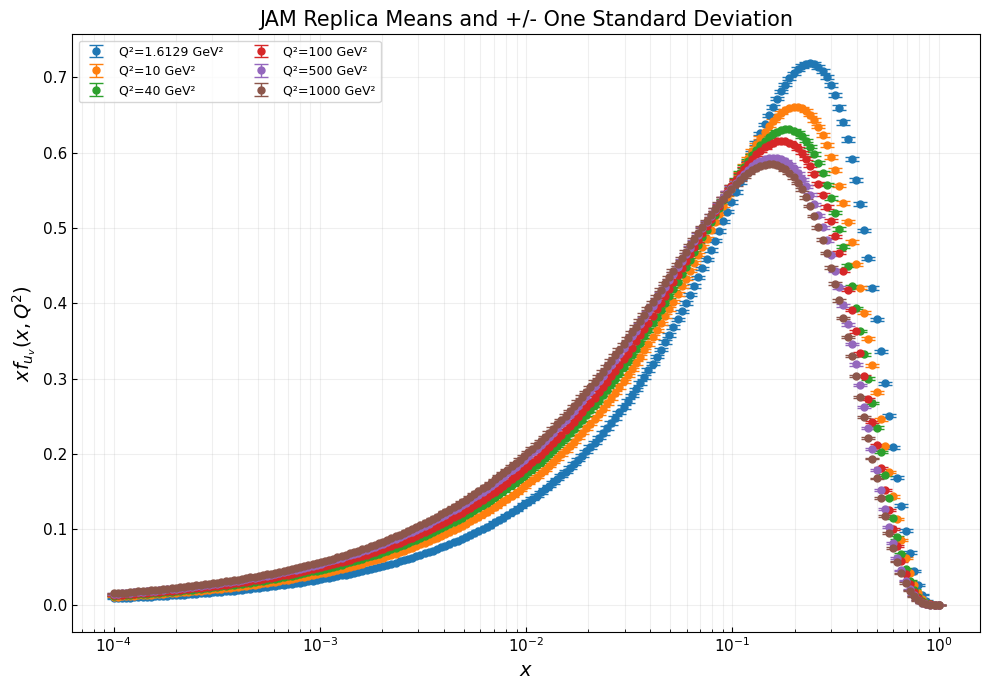

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
zip_path = '/work/JAM/rathman/trey24_no_sidis_lo_extended.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()
        
# ── 2. x-grid  ──────────────
N_x   = 200
X     = 10**np.linspace(-4, np.log10(1), N_x) 

log_x = np.log(X)

Q2_vals = [1.6129, 10, 40, 100, 500, 1000]
VAL_Q2  = 40.0
CF = 4.0 / 3.0

print(f'Loaded: {zip_path}')
print(f'N_x: {N_x}  |  x grid: {X.min():.2e} to {X.max():.8f}')
print(f'Q² values: {Q2_vals}')
print(f'Replica shape at Q²=1.6129: {treypdf[1.6129]["uv"].shape}')
print('Extended Q² values:')
print(treypdf.keys())

# ── 3. Plot Data from file ──────────────
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    uv_reps      = treypdf[q2]['uv']
    uv_mean      = np.mean(uv_reps, axis=0)
    uv_std       = np.std(uv_reps, axis=0)

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X, uv_mean, yerr=uv_std, fmt='o', capsize=5, elinewidth=1.0, markersize = 5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

## Define Running Coupling

In [4]:
class ALPHAS:

    def __init__(self,order=1):
        """
        order=0: 1-loop
        order=1: 2-loops
        """
        if 'order' in conf: order=conf['order']
        self.order=order
        self.mu20=1
        self.setup()

    def setup(self):
        aux = conf['aux']

        #--setup the beta function
        self.beta=np.zeros((7,3))
        for Nf in range(3,7):
            self.beta[Nf,0]=11.0-2.0/3.0*Nf
            self.beta[Nf,1]=102.-38.0/3.0*Nf
            self.beta[Nf,2]=2857.0/2.0-5033.0/18.0*Nf+325.0/54.0*Nf**2

        # uses alphaS(mZ)--> backwards evolution
        self.aZ  = conf['aux'].alphaSMZ/(4*np.pi)
        self.ab=self.evolve_a(self.aZ,aux.mZ2,aux.mb2,5)
        self.ac=self.evolve_a(self.ab,aux.mb2,aux.mc2,4)
        self.a0=self.evolve_a(self.ac,aux.mc2,self.mu20,3)

        # we will store all Q2 values of alphaS
        self.storage={}


    def get_Nf(self,mu2):
        aux = conf['aux']
        Nf=3
        if mu2>=(aux.mc2): Nf+=1
        if mu2>=(aux.mb2): Nf+=1
        return Nf

    def beta_func(self,a,Nf):
        betaf = -self.beta[Nf,0]
        if self.order>=1: betaf+=-a*self.beta[Nf,1]
        if self.order>=2: betaf+=-a*self.beta[Nf,2]
        return betaf*a**2

    def evolve_a(self,a0,mu20,mu2,Nf):
        # Runge-Kutta implemented in pegasus
        LR = np.log(mu2/mu20)/20.0
        a=a0
        for k in range(20):
            XK0 = LR * self.beta_func(a,Nf)
            XK1 = LR * self.beta_func(a + 0.5 * XK0,Nf)
            XK2 = LR * self.beta_func(a + 0.5 * XK1,Nf)
            XK3 = LR * self.beta_func(a + XK2,Nf)
            a+= (XK0 + 2.* XK1 + 2.* XK2 + XK3) * 0.166666666666666
        return a

    def get_a(self,mu2):
        aux = conf['aux']

        if mu2 not in self.storage:

            if aux.mb2<=mu2:
                mu20,a0,Nf=aux.mb2,self.ab,5
            elif aux.mc2<=mu2 and mu2<aux.mb2:
                mu20,a0,Nf=aux.mc2,self.ac,4
            elif mu2<aux.mc2:
                mu20,a0,Nf=self.mu20,self.a0,3
            self.storage[mu2]=self.evolve_a(a0,mu20,mu2,Nf)

        return self.storage[mu2]

    def get_alphaS(self,mu2):
        return self.get_a(mu2)*4*np.pi

conf = {}
conf['aux']   = AUX()
conf['order'] = 0    # LO running: one-loop beta function, consistent with LO splitting function
mu2=conf['aux'].mZ2

alphas_runner = ALPHAS()


In [5]:
# Precompute running alpha_s for all training Q² values.
# get_alphaS returns a Python float; convert to float32 scalar tensor
# for use inside dglap_convolution which operates in torch.
alphas_Q2 = {
    q2: torch.tensor(alphas_runner.get_alphaS(q2), dtype=torch.float32, device=device)
    for q2 in Q2_vals
}

print('Running alpha_s values:')
for q2, a in alphas_Q2.items():
    print(f'  Q² = {q2:>8.4f} GeV²  →  alpha_s = {a.item():.6f}')

Running alpha_s values:
  Q² =   1.6129 GeV²  →  alpha_s = 0.319246
  Q² =  10.0000 GeV²  →  alpha_s = 0.230247
  Q² =  40.0000 GeV²  →  alpha_s = 0.191625
  Q² = 100.0000 GeV²  →  alpha_s = 0.173084
  Q² = 500.0000 GeV²  →  alpha_s = 0.147941
  Q² = 1000.0000 GeV²  →  alpha_s = 0.139230


## Build Training/Validation Tensors & Define Collocation Grid

The training and valiation tensors are then constructed from the file data. The neural network target will be the JAM UV mean at $Q^2$ = 10, 40, 100, & 1000, which serve as the boundary conditions to guide the network in the PDF's kinematic dependence.

PDF data at $Q^2=500$ is used to build a validation tensor, which will indicate the network's ability to generalize to unseen data. The standard deviation of the data is also calculated here, as it will be used later in the $\chi^2$ loss calculation.

The collocation grid includes all 200 $X \in [10^{-4}, 1]$. This grid defines (x, Q^2) points where the DGLAP covolution and valence quark sum rule integrals will be evaluated.

In [6]:
train_inp, train_tgt = [], []
val_inp,   val_tgt   = [], []
train_std_list = []
val_std_list   = []

# Initial scale PDF (Q0^2 reference curve)
Q0 = 1.6129
init_reps = treypdf[Q0]['uv']              # shape (n_replicas, N_x)
init_pdf  = np.mean(init_reps, axis=0)     # shape (N_x,)
init_pdf_std = np.std(init_reps, axis=0)   # shape (N_x,)

for q2 in Q2_vals:
    uv_reps = treypdf[q2]['uv']            # (n_replicas, N_x)
    uv_mean = np.mean(uv_reps, axis=0)     # (N_x,)
    uv_std  = np.std(uv_reps, axis=0)      # (N_x,)
    ln_q2 = np.log(q2)
    inp = np.concatenate([init_pdf, [ln_q2]])   # shape (N_x + 1,)
    tgt = uv_mean                                # shape (N_x,)
    if q2 != VAL_Q2 and q2 != Q0:
        train_inp.append(inp)
        train_tgt.append(tgt)
        train_std_list.append(uv_std)           
    if q2 == VAL_Q2:
        val_inp.append(inp)
        val_tgt.append(tgt)
        val_std_list.append(uv_std)              

train_X = torch.tensor(np.stack(train_inp), dtype=torch.float32, device=device)   # (N_train, N_x+1)
train_Y = torch.tensor(np.stack(train_tgt), dtype=torch.float32, device=device)   # (N_train, N_x)
val_X   = torch.tensor(np.stack(val_inp),   dtype=torch.float32, device=device)
val_Y   = torch.tensor(np.stack(val_tgt),   dtype=torch.float32, device=device)
train_STD = torch.tensor(np.stack(train_std_list), dtype=torch.float32, device=device)  # (N_train, N_x)
val_STD   = torch.tensor(np.stack(val_std_list),   dtype=torch.float32, device=device)  # (N_val, N_x)

print("train_X:", train_X.shape, train_X.device)
print("train_Y:", train_Y.shape, train_Y.device)
print("train_STD:", train_STD.shape, train_STD.device)
print("val_X:", val_X.shape, val_X.device)
print("val_Y:", val_Y.shape, val_Y.device)
print("val_STD:", val_STD.shape, val_STD.device)

# CHANGE: dedicated input-scale boundary-condition tensor.
# This is intentionally NOT part of train_X/colloc_X. It is a single point at
# ln(Q0^2), input = [init_pdf, ln(Q0^2)], target = init_pdf itself (identity map).
# Kept separate so it can never leak into the DGLAP or sum-rule pipelines,
# which only ever see train_X / colloc_X / quad_X.
bc_inp = np.concatenate([init_pdf, [np.log(Q0)]])   # shape (N_x + 1,)
bc_tgt = init_pdf                                    # shape (N_x,)

bc_X = torch.tensor(bc_inp[None, :], dtype=torch.float32, device=device)  # (1, N_x+1)
bc_Y = torch.tensor(bc_tgt[None, :], dtype=torch.float32, device=device)  # (1, N_x)

print("bc_X:", bc_X.shape, bc_X.device)
print("bc_Y:", bc_Y.shape, bc_Y.device)

x_grid_t = torch.tensor(X, dtype=torch.float32).to(device)

train_X: torch.Size([4, 201]) cuda:0
train_Y: torch.Size([4, 200]) cuda:0
train_STD: torch.Size([4, 200]) cuda:0
val_X: torch.Size([1, 201]) cuda:0
val_Y: torch.Size([1, 200]) cuda:0
val_STD: torch.Size([1, 200]) cuda:0
bc_X: torch.Size([1, 201]) cuda:0
bc_Y: torch.Size([1, 200]) cuda:0


In [7]:
x_grid_t = torch.tensor(X, dtype=torch.float32).to(device)

# Reuse train_X as the collocation input — same filtering (q2 != VAL_Q2 and q2 != Q0),
# same construction (init_pdf concatenated with ln(q2)), so no need to rebuild it
colloc_X = train_X

# colloc_np is still useful downstream (e.g. for np.argmin lookups on lnQ² in the training loop)
colloc_np = train_X.cpu().numpy()

print(f'Collocation grid: {colloc_X.shape}')
print("x_grid range:", x_grid_t.min().item(), x_grid_t.max().item())

Collocation grid: torch.Size([4, 201])
x_grid range: 9.999999747378752e-05 1.0


## Define GL Weights for DGLAP and Sum Rule Integrals

Next, we define quadrature nodes and weights to numerically approximate the DGLAP convolution and the valence quark sum rule integrals with Gauss-Legendre Quadrature. We use the Numpy legendre.leggauss function to generate the nodes and weights for each integral approximation (n=16 for DGLAP and n=32 for SR, each number of weights was chosen by examining the convergence of the integral over various n).

In [8]:
# ── Gauss-Legendre nodes and weights (for DGLAP convolution) ────────────────
from numpy.polynomial.legendre import leggauss

N_GL = 16
gl_nodes_np, gl_weights_np = leggauss(N_GL)
gl_nodes   = torch.tensor(gl_nodes_np,   dtype=torch.float32, device=device)
gl_weights = torch.tensor(gl_weights_np, dtype=torch.float32, device=device)
print(f'GL nodes: {gl_nodes.shape}, GL weights sum={gl_weights.sum().item():.6f} (should = 2.0)')

GL nodes: torch.Size([16]), GL weights sum=2.000000 (should = 2.0)


For the valence quark sum rule integral, we will employ a change of variables, $t=-ln(x)$, so $x = e^{-t}$, then:

$\qquad dx = -e^{-t}\, dt = -x\, dt$

Since the valence up quark sum rule is defined as: $\int_0^1 f_{u_v}(x)\, dx = 2$,

the transformation to t variables is:
$\int_0^1 f_{u_v}(x)\, dx
= \int_{T_{\max}}^{T_{\min}} f_{u_v}(e^{-t})\,\left(-e^{-t}\right) dt
= \int_{T_{\min}}^{T_{\max}} e^{-t}\, f_{u_v}(e^{-t})\, dt$

Notice that the Jacobian will cancel with the momentum-weighted PDF: $e^{-t}\, f_{u_v}(e^{-t}) = x\, f_{u_v}(x) = x f_{u_v}(x)\Big|_{x = e^{-t}}$

so,
$\int_0^1 f_{u_v}(x)\, dx = \int_{T_{\min}}^{T_{\max}} xf_{u_v}(x)\Big|_{x=e^{-t}}\, dt = 2$

We then will need to perform an affine transformation of the nodes and weights to the actual integration domain, since GL Quad theory only defines them on $x \in [-1, 1]$,

$t_j = \frac{T_{\max}+T_{\min}}{2} + \frac{T_{\max}-T_{\min}}{2}\,\xi_j, \qquad j = 1,\dots,n$

Finally, we arrive at the result:

$\int_0^1 f_{u_v}(x)\, dx
\approx \frac{T_{\max}-T_{\min}}{2}\sum_{j=1}^{n} w_j\; xf_{u_v}(x_j)\Big|_{x_j = e^{-t_j}}
= 2$

In [9]:
# ── GL nodes for sum rule in t = -ln(x) space ───────────────────────────────
from numpy.polynomial.legendre import leggauss

N_GL_SR  = 32
SR_X_MAX = 1.0            # x = 1  -> T_MIN = 0
SR_X_MIN = X.min()        # 1e-4 
                          

T_MIN = -np.log(SR_X_MAX)   # = 0
T_MAX = -np.log(SR_X_MIN)   # ≈ 9.21

gl_nodes_sr_np, gl_weights_sr_np = leggauss(N_GL_SR)

half_range_sr = (T_MAX - T_MIN) / 2.0
mid_sr        = (T_MAX + T_MIN) / 2.0

t_sr_nodes_np = mid_sr + half_range_sr * gl_nodes_sr_np   # (N_GL_SR,) in t-space
x_sr_nodes_np = np.exp(-t_sr_nodes_np)                     # mapped back to x

x_sr_nodes    = torch.tensor(x_sr_nodes_np,    dtype=torch.float32, device=device)
t_sr_nodes    = torch.tensor(t_sr_nodes_np,    dtype=torch.float32, device=device)
gl_weights_sr = torch.tensor(gl_weights_sr_np, dtype=torch.float32, device=device)
log_x_sr      = -t_sr_nodes   # ln(x) = -t, kept in case a network input needs it

print(f'SR GL nodes: {N_GL_SR}')
print(f'Integration domain (x): [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')
print(f'Integration domain (t): [{T_MIN:.4f}, {T_MAX:.4f}]')
print(f'Jacobian (T_MAX-T_MIN)/2: {half_range_sr:.6f}')
print(f'Smallest x node: {x_sr_nodes_np.min():.3e}  (t = {t_sr_nodes_np.max():.4f})')
print(f'Largest  x node: {x_sr_nodes_np.max():.6f}  (t = {t_sr_nodes_np.min():.4f})')

SR GL nodes: 32
Integration domain (x): [1.0e-04, 1.000000]
Integration domain (t): [-0.0000, 9.2103]
Jacobian (T_MAX-T_MIN)/2: 4.605170
Smallest x node: 1.013e-04  (t = 9.1977)
Largest  x node: 0.987479  (t = 0.0126)


## Leading-Order NS DGLAP Convolution

Previously we defined the LO non-singlet splitting function $P_{qq}(z)$ as:

$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$


We then examined a regularized alternative form
:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$

Which, when integrated inside the DGLAP equation, becomes:

$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$


Now, we define a function to numerically approximate the RHS of the NS DGLAP equation at LO (after taking $ t = ln(y)$, so $y = e^{t}$ ) with the limits: 

$$T_{\min} = \ln x, \qquad T_{\max} = 0.$$

$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} C_F
\left[
    \int_{\ln x}^{0}
    \frac{1 + \left(\frac{x}{e^t}\right)^2}{1 - \frac{x}{e^t}}
    \left[ f(e^t) - \frac{x}{e^t}\, f(x) \right] dt
    + \left( \frac{3}{2} + 2\ln(1-x) \right) f(x)
\right]$$

Notice that, unlike the sum rule integral, there is no explicit Jacobian factor multiplying the integrand here, since $dy/y = dt$ exactly — the $1/y$ measure is absorbed directly into the substitution rather than appearing as a residual prefactor.

We then will need to perform an affine transformation of the nodes and weights to the actual integration domain, since GL Quad theory only defines them on $\xi \in [-1, 1]$,

$$t_j(x) = \frac{T_{\max}+T_{\min}}{2} + \frac{T_{\max}-T_{\min}}{2}\,\xi_j = \frac{\ln x}{2}\big(1 - \xi_j\big), \qquad j = 1,\dots,n,$$

with corresponding $y$-space nodes

$$y_j(x) = e^{t_j(x)}.$$

Finally, we arrive at the result:

$$\int_x^1 \frac{dy}{y}\, P_{qq}\!\left(\frac{x}{y}\right) \Big[q_{NS}(y) - \tfrac{x}{y}q_{NS}(x)\Big] \approx \frac{T_{\max}-T_{\min}}{2}\sum_{j=1}^{n} w_j\; P_{qq}\big(z_j\big)\Big[q_{NS}(y_j) - z_j\, q_{NS}(x)\Big]\Big|_{y_j = e^{t_j}},$$

which, combined with the virtual correction, gives the full RHS of the NS DGLAP equation:

$$\int_x^1 \frac{dy}{y}\, P_{qq}\!\left(\frac{x}{y}\right) q_{NS}(y) \approx \frac{T_{\max}-T_{\min}}{2}\sum_{j=1}^{n} w_j\; P_{qq}(z_j)\Big[q_{NS}(y_j) - z_j\,q_{NS}(x)\Big] + C_F\left(\frac{3}{2}+2\ln(1-x)\right) q_{NS}(x).$$

In [10]:
def dglap_convolution_gl(xf_fn, x_grid, gl_nodes, gl_weights, alpha_s):
    """
    xf_fn    : callable — takes a tensor of x values, returns xf(x).
               With the new NN architecture, xf_fn should be built by:
               - evaluating the model once on the fixed x_grid for a given Q²
               - interpolating that output to arbitrary y values needed by GL.
    x_grid   : (N_x,) query points — the x values we want the RHS at
    gl_nodes : (N_GL,) Gauss-Legendre nodes on [-1, 1]
    gl_weights: (N_GL,) corresponding weights
    alpha_s  : scalar tensor
    """
    N_x  = x_grid.shape[0]
    N_GL = gl_nodes.shape[0]
    ln_xi = torch.log(x_grid)           # (N_x,)   ln(x_i) — negative values

    # ── Map GL nodes to [ln(x_i), 0] for every query point ──────────────────
    # t_nodes[i, j] = GL node j mapped to the integration domain of query i
    # shape: (N_x, N_GL)
    half_range = -ln_xi / 2.0           # (N_x,)   = |ln(x_i)| / 2
    t_mid      = ln_xi / 2.0            # (N_x,)   midpoint of [ln(x_i), 0]

    t_nodes = t_mid.unsqueeze(1) + half_range.unsqueeze(1) * gl_nodes.unsqueeze(0)
    # t_nodes[i, j] = ln(x_i)/2 * (1 - xi_j), shape: (N_x, N_GL)

    y_nodes = torch.exp(t_nodes) 

    # ── Evaluate the PDF at the GL nodes ────────────────────────────────────
    # This is the key difference from Simpson: we need f at arbitrary y values,
    # not just the fixed x-grid. xf_fn must accept a flat tensor and return xf.
    y_flat    = y_nodes.reshape(-1)     # (N_x * N_GL,)
    xf_y_flat = xf_fn(y_flat)          # (N_x * N_GL,)
    xf_y      = xf_y_flat.reshape(N_x, N_GL)   # (N_x, N_GL)
    f_y       = xf_y / y_nodes         # f(y) = xf(y)/y

    # ── Plus-prescription subtraction ────────────────────────────────────────
    # FIX (issue 4): cache xf_fn(x_grid) to avoid a second identical
    # forward pass in the virtual term below.
    xf_at_x = xf_fn(x_grid)                              # single cached call
    f_x     = (xf_at_x / x_grid).unsqueeze(1)            # (N_x, 1)
    z   = x_grid.unsqueeze(1) / y_nodes            # (N_x, N_GL)

    kernel    = (1 + z**2) / (1 - z + 1e-12)       # (N_x, N_GL)  P(z)
    integrand = kernel * (f_y - z * f_x)            # (N_x, N_GL)
  
    # ── Weighted sum with Jacobian ────────────────────────────────────────────
    # Jacobian = half_range = |ln(x_i)| / 2, shape (N_x,)
    jacobian   = half_range.unsqueeze(1)            # (N_x, 1)
    real_term  = (jacobian * (integrand * gl_weights.unsqueeze(0))).sum(dim=1)

    # ── Virtual correction ────────────────────────────────────────────────────
    log_1mx  = torch.log(1.0 - x_grid + 1e-12)
    f_x_diag = xf_at_x / x_grid   # FIX (issue 4): reuse cached result
    virtual  = (1.5 + 2.0 * log_1mx) * f_x_diag

    prefactor = alpha_s / (2 * torch.pi)
    return prefactor * CF * (real_term + virtual)

Now we define the make_xf_fn, which will allow us to evaluate the model at the given GL nodes by interpolating the NN output to be continuous across the x-grid. We use log-linear interpolation. 

In [11]:
def make_xf_fn(x_grid, xf_grid):
    """Returns interpolated xf_uv(y) at defined GL nodes"""
    # Convert to log-space
    log_x  = torch.log(x_grid)
    log_xf = torch.log(xf_grid.clamp(min=1e-8))

    def xf_fn(y):
        y_clamped = y.clamp(min=x_grid[0].item(), max=x_grid[-1].item())
        log_y = torch.log(y_clamped)
        idx = torch.searchsorted(log_x, log_y).clamp(1, len(log_x)-1)
    
    #def xf_fn(y):
        #log_y = torch.log(y)
        # Find bracketing grid points
        #idx = torch.searchsorted(log_x, log_y).clamp(1, len(log_x)-1)

        x0 = log_x[idx - 1]
        x1 = log_x[idx]
        f0 = log_xf[idx - 1]
        f1 = log_xf[idx]

        # Linear interpolation in log-space
        t = (log_y - x0) / (x1 - x0)
        log_f = f0 + t * (f1 - f0)

        return torch.exp(log_f)

    return xf_fn

## Define Neural Network & Hyperparameters

Now we finally define the neural network, which takes in $(xf_{uv}(Q_{0}^2), ln(Q^2))$, where $xf_{uv}(Q_{0}^2)$ is an array of the PDF at $Q_{0}^2 =1.6129$ on a grid 200 $X_B$ values. The network then outputs $xf_{uv}(Q^2)$, the evolved PDF at the corresponding input $ln(Q^2)$, as an array on the grid. The positivity of the output PDF prediction (for LO PDFs) is enforced by a final Softplus layer. Currently, hyperbolic tanget activation functions are used.

* The network width/depth has been changed from previous notebooks since the PINN is now doing function-to-function learning rather than pointwise learning. Because of this, the width of each layer has been increased from 64 to 256 and the depth was decreased from 6 hidden layers to 3.

For training, the Adam optimizer and CosineAnnealing learning rate scheduler are used. To prevent overfitting, the early stop patience metric tracks the number of epochs over which the validation RAE does not improve. Once the count reaches EARLY_STOP_PATIENCE, training terminates.

In [12]:
class PINN(nn.Module):
    def __init__(self, N_x):
        super().__init__()

        # Input: initial PDF (N_x) + ln(Q^2) (1) = N_x + 1
        in_dim  = N_x + 1
        out_dim = N_x

        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, out_dim), nn.Softplus()
        )

        # Xavier initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, inp):
        # inp shape: (batch, N_x + 1)
        # output: (batch, N_x)
        return self.net(inp)

    def chi_square_loss(self, pred, jam_mean, jam_std):
        epsilon = 1e-6
        return torch.mean(((pred - jam_mean) / (jam_std + epsilon))**2)

    def relative_absolute_error(self, pred, jam_mean):
        epsilon = 1e-6
        return torch.mean(torch.abs((pred - jam_mean) / (jam_mean + epsilon)))

model = PINN(N_x).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=200, bias=True)
    (7): Softplus(beta=1.0, threshold=20.0)
  )
)
Parameters: 234696


In [13]:
N_TRAIN             = train_X.shape[0]

BATCH_SIZE          = N_TRAIN
N_EPOCHS            = 60000
LOG_EVERY           = 5000
EARLY_STOP_PATIENCE = 1000
LAMBDA_DGLAP        = 1000 
LAMBDA_DATA         = 1
LAMBDA_SR           = 100#10000
LAMBDA_BC           = 1000#1000

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = N_EPOCHS)


## Training Loop with SR Dict & GL Quad

In [14]:
# --- Prepare tensors used in the loop ------------------------------------------------
init_pdf_t   = torch.tensor(init_pdf, dtype=torch.float32, device=device)   # (N_x,)
colloc_X_t   = torch.tensor(colloc_np, dtype=torch.float32, device=device)  # (N_colloc, N_x+1)
N_colloc     = colloc_X_t.shape[0]
N_x          = x_grid_t.shape[0]

# train Q2 list (exclude Q0 and validation)
train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2 and q2 != Q0]
N_TRAIN = train_X.shape[0]

# bookkeeping
train_losses, val_losses = [], []
data_losses_log, phys_losses_log, sr_losses_log = [], [], []
bc_losses_log = []   # CHANGE: log BC loss per epoch alongside the other three
train_rae_log, val_rae_log = [], []
best_val_loss = float('inf')
best_val_rae  = float('inf')
best_state    = None
no_improve    = 0
best_sr_residuals = {}
t0 = time.time()

print(f'Training samples    : {N_TRAIN}')
print(f'Batch size          : {N_TRAIN} (full-batch)')
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')
print(f'Lambda Data         : {LAMBDA_DATA}')
print(f'Lambda DGLAP        : {LAMBDA_DGLAP}')
print(f'Lambda Sum Rule     : {LAMBDA_SR}')
print(f'Lambda BC           : {LAMBDA_BC}')   # CHANGE: confirm the new weight at startup
print(f'DGLAP Q2 values     : {train_Q2_vals}')
print('Starting...')

# --- Training loop -----------------------------------------------------------------
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # ---- (a) Data loss (full-batch) ------------------------------------
    pred_train = model(train_X)   # (N_train, N_x)
    data_loss  = model.chi_square_loss(pred_train, train_Y, train_STD)

    # ---- (a2) BC loss (full-batch, single row) --------------------------
    # CHANGE: new loss station. bc_X/bc_Y are dedicated tensors built earlier,
    # never part of train_X or colloc_X, so this never touches DGLAP or SR.
    pred_bc = model(bc_X)  
    bc_loss = torch.mean((pred_bc - bc_Y)**2)

    # ---- (b) Collocation: make lnQ2 column require grad -----------------
    # colloc_X_t layout: [ init_pdf (N_x entries) , lnQ2 ] per row
    colloc_inp = colloc_X_t.clone().detach()
    lnq2_col = colloc_inp[:, -1].unsqueeze(1).clone().detach().requires_grad_(True)   # (N_colloc, 1)
    colloc_inp = torch.cat([colloc_inp[:, :-1], lnq2_col], dim=1)                     # (N_colloc, N_x+1)

    # Evaluate model on collocation rows: returns (N_colloc, N_x)
    xf_colloc = model(colloc_inp)   # (N_colloc, N_x)

    # ---- (c) Compute d(xf)/d(lnQ2) for each collocation row and each x ----
    dxf_dlnq2_cols = []
    for k in range(N_x):
        grads_k = torch.autograd.grad(
            outputs = xf_colloc[:, k],
            inputs  = lnq2_col,
            grad_outputs = torch.ones_like(xf_colloc[:, k]),
            retain_graph = True,
            create_graph  = True,
            allow_unused = False
        )[0]   
        dxf_dlnq2_cols.append(grads_k.squeeze(1))   # (N_colloc,)

    dxf_dlnq2 = torch.stack(dxf_dlnq2_cols, dim=1)   # (N_colloc, N_x)

    # ---- (d) Loop over training Q2 values to build DGLAP residuals & SR ----
    dglap_residuals = []
    sr_residuals    = []
    sr_integrals_for_logging = {}

    colloc_lnq2_vals = colloc_np[:, -1]
    for i, q2 in enumerate(train_Q2_vals):
        lnq2_val = np.log(q2)
        idx = int(np.argmin(np.abs(colloc_lnq2_vals - lnq2_val)))

        xf_q2  = xf_colloc[idx, :].squeeze()    # (N_x,)
        dxf_q2 = dxf_dlnq2[idx, :].squeeze()    # (N_x,)
        df_dlnq2 = dxf_q2 / x_grid_t            # (N_x,)

        xf_fn_q2 = make_xf_fn(x_grid_t, xf_q2)
        rhs = dglap_convolution_gl(xf_fn_q2, x_grid_t, gl_nodes, gl_weights, alphas_Q2[q2])

        half_range = (-torch.log(x_grid_t) / 2.0).detach()
        xf_scale = xf_q2.detach().clamp(min=1e-3) / x_grid_t
        combined_scale = xf_scale * half_range.clamp(min=1.0)

        residual_normalized = (df_dlnq2 - rhs) / combined_scale
        dglap_residuals.append(residual_normalized)

        xf_at_sr_nodes = xf_fn_q2(x_sr_nodes)
        integral_val = half_range_sr * torch.sum(gl_weights_sr * xf_at_sr_nodes)
        sr_integrals_for_logging[q2] = integral_val.item()
        sr_residuals.append(integral_val - 2.0)

    # ---- (e) Loss assembly ----------------------------------------------
    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2)

    total_loss = (LAMBDA_DATA * data_loss
                  + LAMBDA_DGLAP * phys_loss
                  + LAMBDA_SR * sr_loss
                  + LAMBDA_BC * bc_loss)   # CHANGE: BC term added, constant weight every epoch/phase

    # --- Compute gradient norms for each loss term (for diagnostics / balancing)
    data_grad_norm = phys_grad_norm = sr_grad_norm = bc_grad_norm = 0.0   # CHANGE: init bc_grad_norm
    compute_grad_norms_every_epoch=False
    
    if epoch % LOG_EVERY == 0 or compute_grad_norms_every_epoch:
        data_grads = torch.autograd.grad(
            LAMBDA_DATA * data_loss, model.parameters(),
            retain_graph=True, allow_unused=True
            )
        data_grad_norm = torch.sqrt(sum((g.norm()**2 for g in data_grads if g is not None))).item()

        phys_grads = torch.autograd.grad(
            LAMBDA_DGLAP * phys_loss, model.parameters(),
            retain_graph=True, allow_unused=True
            )
        phys_grad_norm = torch.sqrt(sum((g.norm()**2 for g in phys_grads if g is not None))).item()

        sr_grads = torch.autograd.grad(
            LAMBDA_SR * sr_loss, model.parameters(),
            retain_graph=True, allow_unused=True
            )
        sr_grad_norm = torch.sqrt(sum((g.norm()**2 for g in sr_grads if g is not None))).item()

        # CHANGE: grad norm for BC loss, same pattern as the other three
        bc_grads = torch.autograd.grad(
            LAMBDA_BC * bc_loss, model.parameters(),
            retain_graph=True, allow_unused=True
            )
        bc_grad_norm = torch.sqrt(sum((g.norm()**2 for g in bc_grads if g is not None))).item()

    # ---- (f) Backprop and step -----------------------------------------
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # ---- (g) Logging / validation --------------------------------------
    model.eval()
    with torch.no_grad():
        val_pred = model(val_X)
        val_loss = model.chi_square_loss(val_pred, val_Y, val_STD).item()
        val_rae  = model.relative_absolute_error(val_pred, val_Y).item()
        train_rae = model.relative_absolute_error(pred_train, train_Y).item()

    train_losses.append(total_loss.item())
    val_losses.append(val_loss)
    data_losses_log.append(data_loss.item())
    phys_losses_log.append(phys_loss.item())
    sr_losses_log.append(sr_loss.item())
    bc_losses_log.append(bc_loss.item())   # CHANGE: log BC loss
    train_rae_log.append(train_rae)
    val_rae_log.append(val_rae)

    # Early stopping / best-state logic (based on val_rae)
    if val_rae < best_val_rae:
        best_val_rae = val_rae
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0

        with torch.no_grad():
            for q2 in Q2_vals:
                ln_q2_sr = torch.full((1,1), np.log(q2), device=device)
                inp_row = torch.cat([init_pdf_t.unsqueeze(0), ln_q2_sr], dim=1)  # (1, N_x+1)
                xf_grid_best = model(inp_row).squeeze()
                xf_fn_best = make_xf_fn(x_grid_t, xf_grid_best)
                xf_at_sr = xf_fn_best(x_sr_nodes)
                integral_best = half_range_sr * torch.sum(gl_weights_sr * xf_at_sr).item()
                best_sr_residuals[q2] = (integral_best - 2.0) / 2.0 * 100.0
    else:
        no_improve += 1

    # Periodic prints
    if epoch % LOG_EVERY == 0:
        elapsed = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS - epoch)
        lr = optimizer.param_groups[0]['lr']
        ratio_dglap_data = phys_loss.item() / (data_loss.item() + 1e-12)
        ratio_sr_data = sr_loss.item() / (data_loss.item() + 1e-12)
        ratio_bc_data = bc_loss.item() / (data_loss.item() + 1e-12)   # CHANGE

        print(f'Epoch {epoch}/{N_EPOCHS} | Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss.item():.2e} | SR: {sr_loss.item():.2e} | '
              f'BC: {bc_loss.item():.2e} | '   # CHANGE: BC added to the main print line
              f'Val RAE: {val_rae:.2e} | LR: {lr:.1e} | No improve: {no_improve} | ETA: {remaining/60:.1f}m')
        print(f'Epoch {epoch:>5} | Data grad norm: {data_grad_norm:.2e} | '
              f'DGLAP grad norm: {phys_grad_norm:.2e} | SR grad norm: {sr_grad_norm:.2e} | '
              f'BC grad norm: {bc_grad_norm:.2e} | '   # CHANGE
              f'DGLAP/Data: {phys_grad_norm/(data_grad_norm+1e-12):.2e} | '
              f'SR/Data: {sr_grad_norm/(data_grad_norm+1e-12):.2e} | '
              f'BC/Data: {bc_grad_norm/(data_grad_norm+1e-12):.2e}')   # CHANGE

        for q2 in train_Q2_vals:
            integral = sr_integrals_for_logging[q2]
            print(f'  Sum rule at Q²={q2:.4f}: ∫xf dx = {integral:.4f} (dev {integral-2.0:+.4f})')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

# --- End training: restore best state -----------------------------------------
if best_state is not None:
    model.load_state_dict(best_state)

print(f'\nDone. Best val RAE: {best_val_rae*100:.4f}%  |  Best val chi²: {best_val_loss:.4e}')
print('\nSum rule % error at best epoch (target = 2.0):')
for q2, pct_err in sorted(best_sr_residuals.items()):
    tag = ' (val)' if q2 == VAL_Q2 else ''
    print(f'  Q²={q2:>8.4f} GeV²{tag}: {pct_err:+.4f}%')

Training samples    : 4
Batch size          : 4 (full-batch)
Early stop patience : 1000
Lambda Data         : 1
Lambda DGLAP        : 1000
Lambda Sum Rule     : 100
Lambda BC           : 1000
DGLAP Q2 values     : [10, 100, 500, 1000]
Starting...
Epoch 5000/60000 | Data: 1.51e+02 | DGLAP: 1.66e-03 | SR: 4.60e-04 | BC: 6.96e-05 | Val RAE: 7.27e-01 | LR: 9.8e-04 | No improve: 0 | ETA: 142.4m
Epoch  5000 | Data grad norm: 2.64e+03 | DGLAP grad norm: 1.39e+01 | SR grad norm: 2.18e+01 | BC grad norm: 4.26e+00 | DGLAP/Data: 5.29e-03 | SR/Data: 8.26e-03 | BC/Data: 1.62e-03
  Sum rule at Q²=10.0000: ∫xf dx = 1.9911 (dev -0.0089)
  Sum rule at Q²=100.0000: ∫xf dx = 1.9757 (dev -0.0243)
  Sum rule at Q²=500.0000: ∫xf dx = 1.9754 (dev -0.0246)
  Sum rule at Q²=1000.0000: ∫xf dx = 1.9762 (dev -0.0238)
Epoch 10000/60000 | Data: 1.45e+01 | DGLAP: 1.03e-03 | SR: 9.96e-04 | BC: 1.62e-05 | Val RAE: 2.30e-01 | LR: 9.3e-04 | No improve: 4 | ETA: 129.1m
Epoch 10000 | Data grad norm: 3.72e+02 | DGLAP grad 

# $X^2$ and RAE vs X

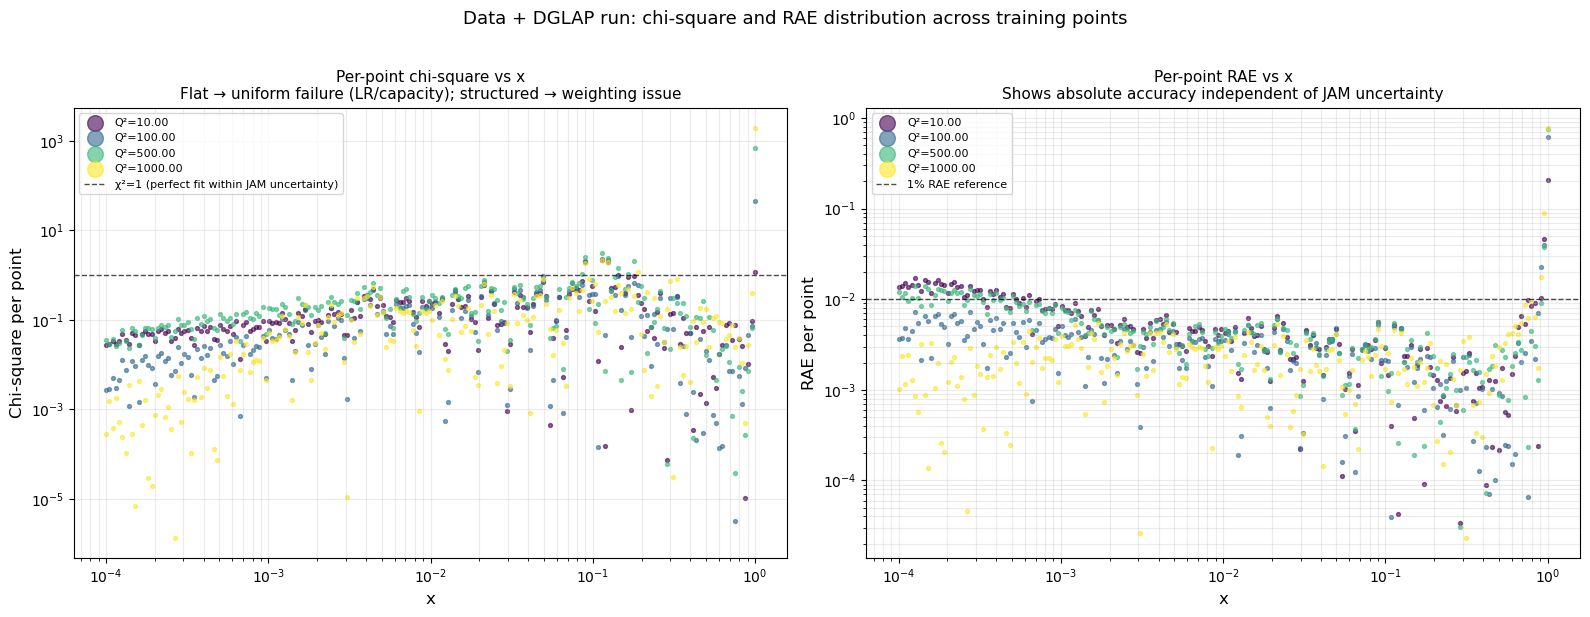

        Q² |    Mean χ² |     Max χ² |  Mean RAE% |   Max RAE%
----------------------------------------------------------
   10.0000 |     0.1879 |     2.1172 |     0.6796 |    20.8141
  100.0000 |     0.3869 |    45.8674 |     0.6385 |    62.2033
  500.0000 |     3.7512 |   698.5087 |     0.8877 |    75.1744
 1000.0000 |     9.6666 |  1903.1672 |     0.6612 |    77.1238

Overall mean chi-square : 3.4981  (target ~1.0 for perfect fit)
Overall mean RAE        : 0.7168%
Fraction with chi² > 10 : 0.4%  (points more than ~3σ from JAM median)


In [15]:
# ── Diagnostic: per-point chi-square error ─────────────
model.eval()

with torch.no_grad():
    pred_train = model(train_X)   # (N_train, N_x)

    # Chi-square per point: ((pred - mu) / sigma)^2
    chi2_per_point = ((pred_train - train_Y) / (train_STD + 1e-12))**2   # (N_train, N_x)
    chi2_np = chi2_per_point.cpu().numpy()

    # RAE per point: |pred - mu| / (|mu| + eps)
    rae_per_point = torch.abs(pred_train - train_Y) / (torch.abs(train_Y) + 1e-6)
    rae_np = rae_per_point.cpu().numpy()

# Extract x and Q² values for colouring
x_vals = x_grid_t.cpu().numpy()                  # shape (N_x,)
q2_vals_train = np.array(train_Q2_vals)          # shape (N_train,)

# ── Plot 1: chi-square per point vs x, coloured by Q² ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
q2_unique = q2_vals_train
colors_diag = plt.cm.viridis(np.linspace(0, 1, len(q2_unique)))

for i, (q2_val, col) in enumerate(zip(q2_unique, colors_diag)):
    ax.scatter(x_vals, chi2_np[i, :],
               s=8, alpha=0.6, color=col, label=f'Q²={q2_val:.2f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Chi-square per point', fontsize=12)
ax.set_title('Per-point chi-square vs x\n'
             'Flat → uniform failure (LR/capacity); '
             'structured → weighting issue', fontsize=11)
ax.axhline(1.0, color='black', lw=1.0, ls='--', alpha=0.7,
           label='χ²=1 (perfect fit within JAM uncertainty)')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

# ── Plot 2: RAE per point vs x, coloured by Q² ───────────────────────────────
ax = axes[1]
for i, (q2_val, col) in enumerate(zip(q2_unique, colors_diag)):
    ax.scatter(x_vals, rae_np[i, :],
               s=8, alpha=0.6, color=col, label=f'Q²={q2_val:.2f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('RAE per point', fontsize=12)
ax.set_title('Per-point RAE vs x\n'
             'Shows absolute accuracy independent of JAM uncertainty', fontsize=11)
ax.axhline(0.01, color='black', lw=1.0, ls='--', alpha=0.7,
           label='1% RAE reference')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

plt.suptitle('Data + DGLAP run: chi-square and RAE distribution across training points',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary statistics per Q² slice ──────────────────────────────────────────
print(f'{"Q²":>10} | {"Mean χ²":>10} | {"Max χ²":>10} | {"Mean RAE%":>10} | {"Max RAE%":>10}')
print('-' * 58)
for i, q2_val in enumerate(q2_unique):
    print(f'{q2_val:>10.4f} | '
          f'{chi2_np[i].mean():>10.4f} | '
          f'{chi2_np[i].max():>10.4f} | '
          f'{rae_np[i].mean()*100:>10.4f} | '
          f'{rae_np[i].max()*100:>10.4f}')

print()
print(f'Overall mean chi-square : {chi2_np.mean():.4f}  (target ~1.0 for perfect fit)')
print(f'Overall mean RAE        : {rae_np.mean()*100:.4f}%')
print(f'Fraction with chi² > 10 : {(chi2_np > 10).mean()*100:.1f}%  '
      f'(points more than ~3σ from JAM median)')


# Plot Training/Validation Loss & Model's PDF Prediction

Let's plot the results of the network training. The training loss represents the total loss:

$\text{total loss} = \lambda_{\text{Data}} \cdot L_{\text{Data}} + \lambda_{\text{DGLAP}} \cdot L_{\text{DGLAP}} + \lambda_{\text{Sum Rule}} \cdot L_{\text{Sum Rule}}$



where $L_{Data}$ is calculated with Chi-Square and $L_{DGLAP}$ & $L_{Sum Rule}$ is calculated with MSE, where Chi-Square is

$$\left(\frac{ \text{ NN Output}\ - f_{uv \text{ JAM mean}}}{\sigma_{uv}}\right)^2$$

The validation loss represents the Chi-Square between the model PDF predictions and the JAM mean PDFs at $Q^2 = 500$.

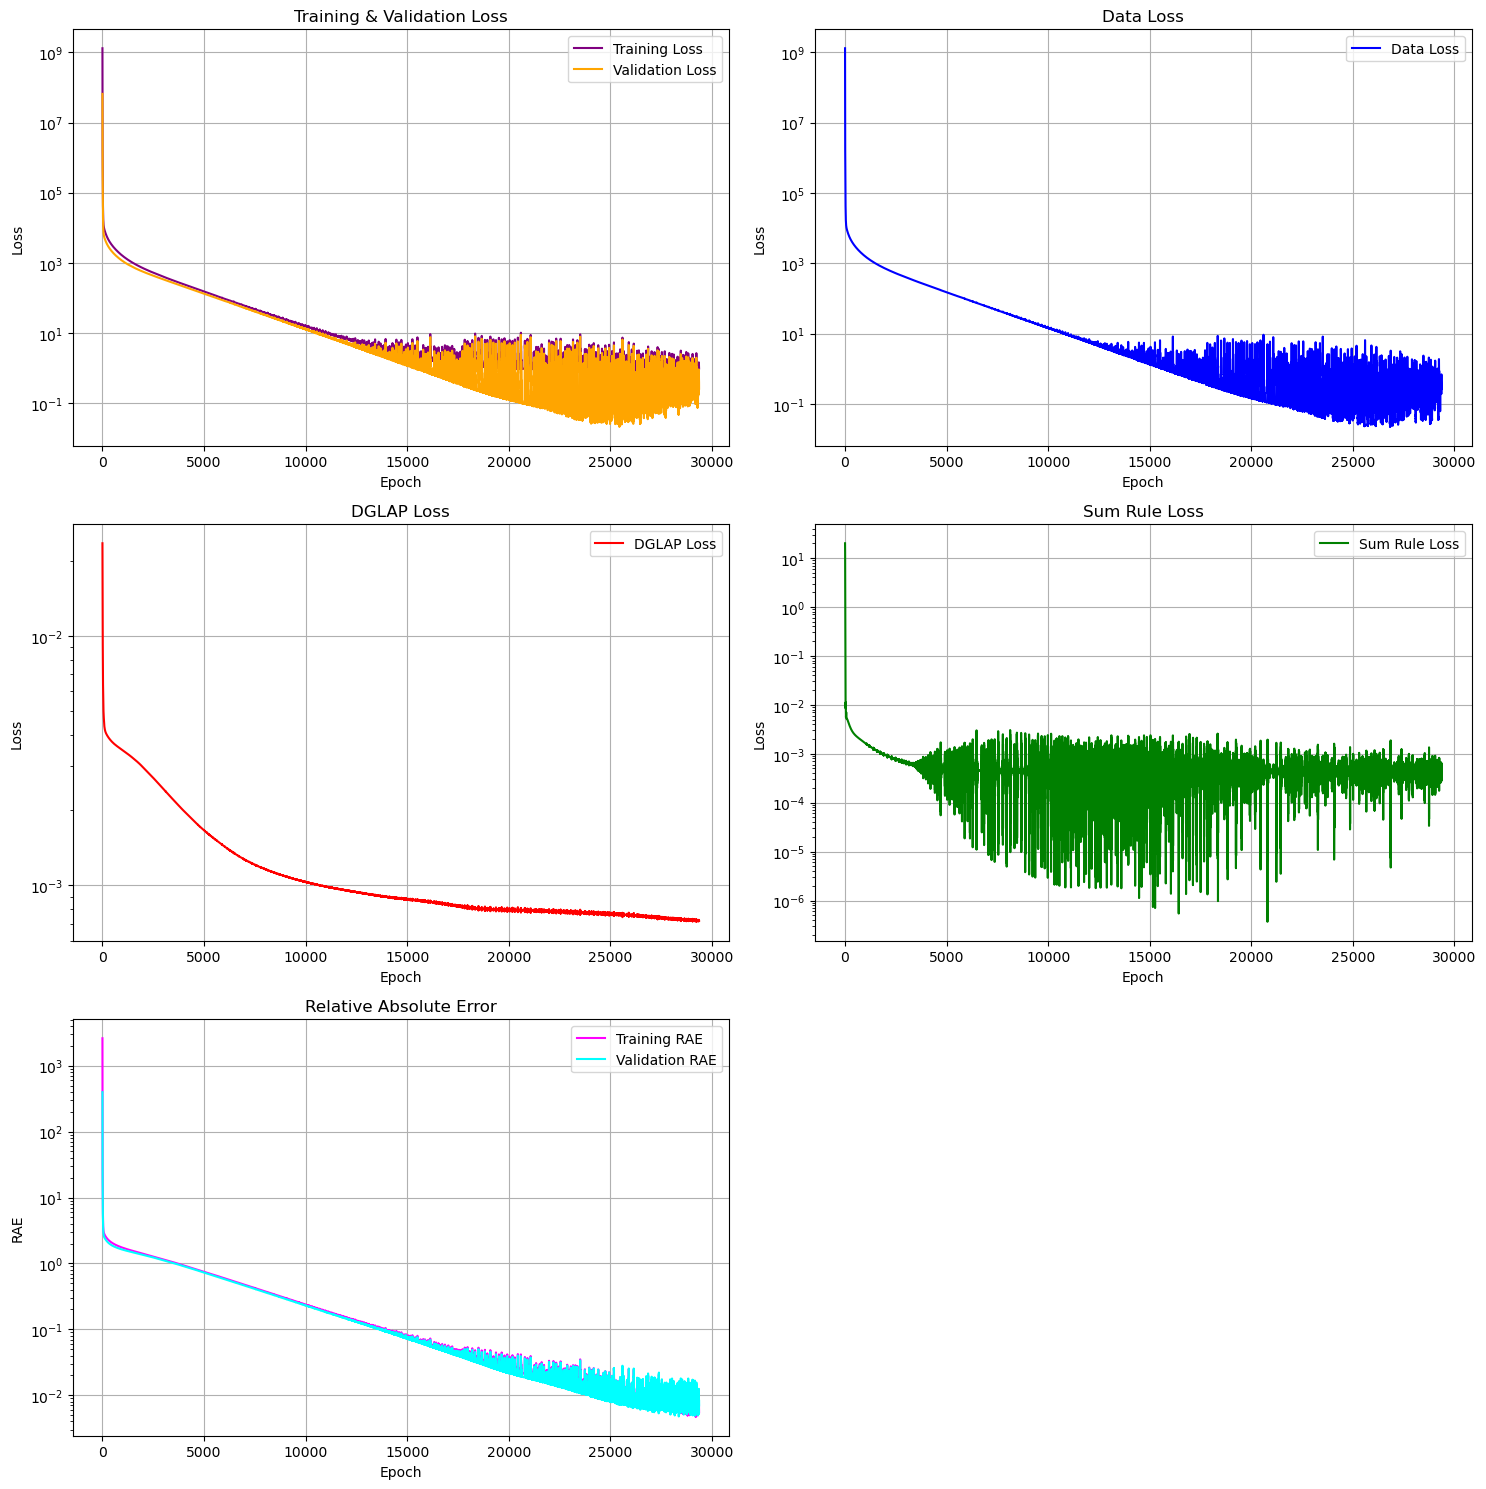

In [16]:
fig, axes_2d = plt.subplots(3, 2, figsize=(15, 15))
axes = axes_2d.flatten()

# --- 1. Training & Validation Loss ---
axes[0].plot(train_losses, label='Training Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_yscale('log')
axes[0].grid(True)
axes[0].legend()

# --- 2. Data Loss ---
axes[1].plot(data_losses_log, label='Data Loss', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Data Loss')
axes[1].set_yscale('log')
axes[1].grid(True)
axes[1].legend()

# --- 3. DGLAP Loss ---
axes[2].plot(phys_losses_log, label='DGLAP Loss', color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('DGLAP Loss')
axes[2].set_yscale('log')
axes[2].grid(True)
axes[2].legend()

# --- 4. Sum Rule Loss ---
axes[3].plot(sr_losses_log, label='Sum Rule Loss', color='green')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Loss')
axes[3].set_title('Sum Rule Loss')
axes[3].set_yscale('log')
axes[3].grid(True)
axes[3].legend()

# --- 5. RAE ---
axes[4].plot(train_rae_log, label='Training RAE', color='magenta')
axes[4].plot(val_rae_log, label='Validation RAE', color='cyan')
axes[4].set_xlabel('Epoch')
axes[4].set_ylabel('RAE')
axes[4].set_title('Relative Absolute Error')
axes[4].set_yscale('log')
axes[4].grid(True)
axes[4].legend()

# --- 6. Hide unused subplot ---
axes[5].set_visible(False)

plt.tight_layout()
plt.show()


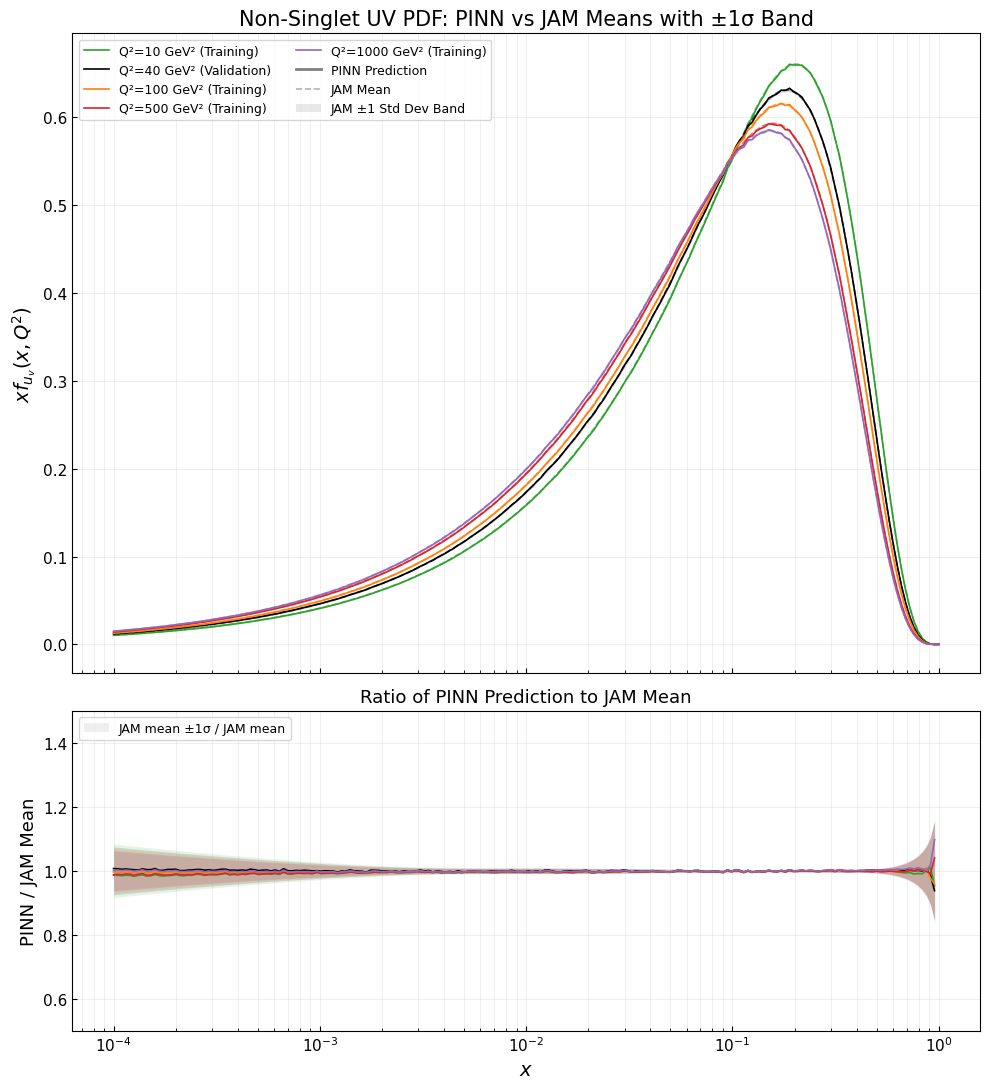

In [17]:
model.eval()

# x-grid (already used in training)
x_vals = x_grid_t.cpu().numpy()          # shape (N_x,)
log_x_vals = np.log(x_vals)

# Colors for Q²
colors = {
    1.6129: '#1f77b4',
    10:     '#2ca02c',
    100:    '#ff7f0e',
    500:    '#d62728',
    1000:   '#9467bd',
}

# Two-panel figure
fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 11),
    gridspec_kw={'height_ratios': [3, 1.5]},
    sharex=True
)

preds_by_q2 = {}
means_by_q2 = {}
los_by_q2   = {}
his_by_q2   = {}

init_pdf_t = torch.tensor(init_pdf, device=device).float()

INPUT_SCALE_Q2 = 1.6129  # skip plotting the model's prediction at its own input scale

for q2 in Q2_vals:
    if q2 == INPUT_SCALE_Q2:
        continue  # not a meaningful prediction — this is the input scale itself

    color = colors.get(q2, 'black')
    label_suffix = ' (Validation)' if q2 == VAL_Q2 else ' (Training)'

    # JAM bands
    uv_reps   = treypdf[q2]['uv']
    mean      = np.mean(uv_reps, axis=0)
    uv_std    = np.std(uv_reps, axis=0)
    lo        = mean - uv_std
    hi        = mean + uv_std

    ax.fill_between(x_vals, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(x_vals, mean, color=color, lw=1.2, ls='--', alpha=0.6)

    # --- PINN input ---
    ln_q2 = np.log(q2)
    ln_q2_t = torch.tensor([ln_q2], device=device).float()
    inp = torch.cat([init_pdf_t, ln_q2_t], dim=0).unsqueeze(0)  # shape (1, N_x+1)

    # NN prediction
    with torch.no_grad():
        pred = model(inp).cpu().numpy().flatten()   # shape (N_x,)

    ax.plot(x_vals, pred, color=color, lw=1.2,
            label=f'Q²={q2} GeV²{label_suffix}')

    preds_by_q2[q2] = pred
    means_by_q2[q2] = mean
    los_by_q2[q2]   = lo
    his_by_q2[q2]   = hi

# --- Top panel formatting ---
line_nn   = plt.Line2D([0], [0], color='grey', lw=2, label='PINN Prediction')
line_med  = plt.Line2D([0], [0], color='grey', lw=1.2, ls='--', alpha=0.6, label='JAM Mean')
line_band = plt.matplotlib.patches.Patch(facecolor='grey', alpha=0.18,
                                         label='JAM ±1 Std Dev Band')

handles_existing, labels_existing = ax.get_legend_handles_labels()
extra_handles = [line_nn, line_med, line_band]
extra_labels  = [h.get_label() for h in extra_handles]

ax.legend(
    handles_existing + extra_handles,
    labels_existing + extra_labels,
    fontsize=9,
    loc='upper left',
    ncol=2
)

ax.set_ylabel(r'$x f_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Means with ±1σ Band', size=15)
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

# --- Ratio panel ---
for q2 in Q2_vals:
    if q2 == INPUT_SCALE_Q2:
        continue  # no prediction to compare — skip in ratio panel too

    color = colors.get(q2, 'black')
    mean  = means_by_q2[q2]
    pred  = preds_by_q2[q2]
    lo    = los_by_q2[q2]
    hi    = his_by_q2[q2]

    safe  = np.abs(mean) > 1e-6
    ratio = np.where(safe, pred / mean, np.nan)
    upper = np.where(safe, hi / mean, np.nan)
    lower = np.where(safe, lo / mean, np.nan)

    ax_ratio.plot(x_vals, ratio, color=color, lw=1.2)
    ax_ratio.fill_between(x_vals, lower, upper, color=color, alpha=0.12, linewidth=0)

ax_ratio.set_xscale('log')
ax_ratio.set_xlabel(r'$x$', size=14)
ax_ratio.set_ylabel(r'PINN / JAM Mean', size=13)
ax_ratio.set_title('Ratio of PINN Prediction to JAM Mean', size=13)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.grid(True, which='both', ls='-', alpha=0.2)
ax_ratio.tick_params(direction='in', which='both', labelsize=11)

band_patch = plt.matplotlib.patches.Patch(
    facecolor='grey', alpha=0.12,
    label='JAM mean ±1σ / JAM mean'
)
ax_ratio.legend(handles=[band_patch], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# SR % Error vs $Q^2$

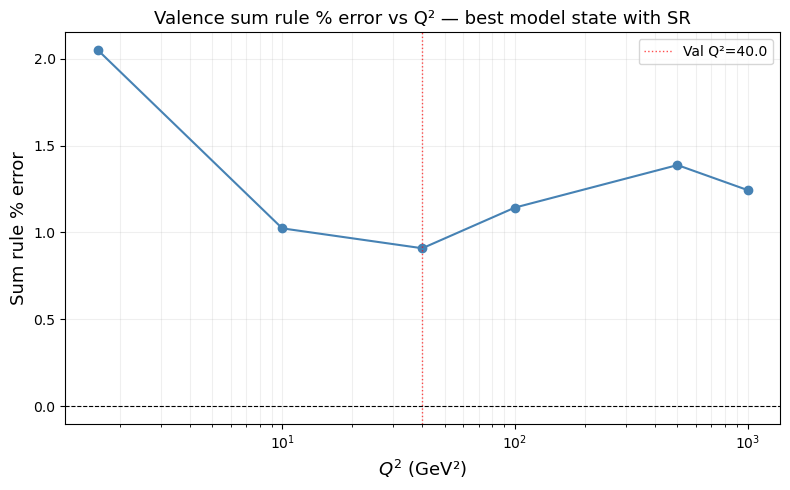

In [18]:
q2_plot  = sorted(best_sr_residuals.keys())
err_plot = [best_sr_residuals[q2] for q2 in q2_plot]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q2_plot, np.abs(err_plot), 'o-', color='steelblue', lw=1.5, ms=6)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(VAL_Q2, color='red', lw=1.0, ls=':', alpha=0.7, label=f'Val Q²={VAL_Q2}')
ax.set_xscale('log')
ax.set_xlabel(r'$Q^2$ (GeV²)', fontsize=13)
ax.set_ylabel('Sum rule % error', fontsize=13)
ax.set_title('Valence sum rule % error vs Q² — best model state with SR', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

# Save Model

In [19]:
save_path = '/work/JAM/rathman/v13_pinn_uv_model.pt'

torch.save({
    # --- Core model + optimizer state ---
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'scheduler_state_dict' : scheduler.state_dict(),

    # --- Training metadata ---
    'best_val_loss'        : best_val_loss,
    'best_val_rae'         : best_val_rae,
    'best_sr_residuals'    : best_sr_residuals,

    # --- PINN architecture metadata ---
    'init_pdf'             : init_pdf,          # initial condition curve
    'x_grid'               : x_grid_t.cpu().numpy(),  # fixed x-grid
    'Q2_vals'              : Q2_vals,           # all Q² used
    'train_Q2_vals'        : train_Q2_vals,     # Q² used for training
    'val_Q2'               : VAL_Q2,            # validation Q²
    'lambda_data'          : LAMBDA_DATA,
    'lambda_dglap'         : LAMBDA_DGLAP,
    'lambda_sr'            : LAMBDA_SR,
    'alpha_s_scheme'       : 'running LO',

    # --- Loss logs ---
    'train_losses'         : train_losses,
    'val_losses'           : val_losses,
    'data_losses'          : data_losses_log,
    'phys_losses'          : phys_losses_log,
    'sr_losses'            : sr_losses_log,
    'train_rae_log'        : train_rae_log,
    'val_rae_log'          : val_rae_log,

    # --- Notes ---
    'notes'                : 'PINN v13 — model takes inputs (xf_uv(Q0^2), ln(Q^2)), where xf_uv(Q0^2) is an array on the 200 x points. The NN outputs xf_uv(Q^2) as an array on the x grid. This model has an input-scale loss term.'
}, save_path)

print(f'Saved to {save_path}')


Saved to /work/JAM/rathman/v13_pinn_uv_model.pt


# Continue Training, re-eval $X^2$ per point

In [23]:
# ── RESUME TRAINING FROM CHECKPOINT ───────────────────────────────────────────

CHECKPOINT_PATH = '/work/JAM/rathman/v12_pinn_uv_model_update.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

print(f'Checkpoint loaded from: {CHECKPOINT_PATH}')

prior_best_val_rae = checkpoint.get('best_val_rae', None)
if prior_best_val_rae is not None:
    print(f'Prior best val RAE: {prior_best_val_rae*100:.4f}%')
else:
    print('Prior best val RAE: not available in checkpoint')

# Restore logs
train_losses  = checkpoint.get('train_losses',  [])
val_losses    = checkpoint.get('val_losses',    [])
data_losses_log = checkpoint.get('data_losses', [])
phys_losses_log = checkpoint.get('phys_losses', [])
sr_losses_log   = checkpoint.get('sr_losses',   [])
train_rae_log = checkpoint.get('train_rae_log', [])
val_rae_log   = checkpoint.get('val_rae_log',   [])

epoch_offset = len(train_losses)
print(f'Resuming from epoch {epoch_offset + 1}')
# ── Hyperparameters for resumed run ───────────────────────────────────────────
N_EPOCHS_RESUME     = 30000
EARLY_STOP_PATIENCE = 1000
LOG_EVERY           = 2000
RESUME_LR           = 5.2e-4

# Restore lambdas
LAMBDA_DATA  = checkpoint.get('lambda_data', 1.0)
LAMBDA_DGLAP = checkpoint.get('lambda_dglap', 1000.0)
LAMBDA_SR    = checkpoint.get('lambda_sr', 10000.0)

# ── Rebuild optimizer and scheduler ───────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=RESUME_LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS_RESUME, eta_min=1e-6
)
# ── Stabilize early-stopping baseline ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    pred_resume      = model(val_X)
    rae_resume       = model.relative_absolute_error(pred_resume, val_Y).item()
    val_loss_resume  = model.chi_square_loss(pred_resume, val_Y, val_STD).item()

best_val_rae       = rae_resume
best_val_loss      = val_loss_resume
best_sr_residuals  = checkpoint.get('best_sr_residuals', None)  # carry forward until improved
best_state         = copy.deepcopy(model.state_dict())
no_improve         = 0

print(f'Stabilized RAE at resume : {best_val_rae*100:.4f}%')
print(f'Resume LR                : {RESUME_LR:.1e}')
print(f'Starting {N_EPOCHS_RESUME} additional epochs...\n')

# ── PINN-specific collocation setup ───────────────────────────────────────────
init_pdf_t = torch.tensor(init_pdf, dtype=torch.float32, device=device)
colloc_X_t = torch.tensor(colloc_np, dtype=torch.float32, device=device)
N_colloc   = colloc_X_t.shape[0]
N_x        = x_grid_t.shape[0]

train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2 and q2 != Q0]

# ── Training loop ─────────────────────────────────────────────────────────────
t0 = time.time()

for epoch in range(1, N_EPOCHS_RESUME + 1):

    model.train()
    optimizer.zero_grad()

    # (a) Data loss (full batch)
    pred_train = model(train_X)
    data_loss  = model.chi_square_loss(pred_train, train_Y, train_STD)

    # (b) Collocation input: [init_pdf, lnQ²]
    colloc_inp = colloc_X_t.clone().detach()
    lnq2_col   = colloc_inp[:, -1].unsqueeze(1).clone().detach().requires_grad_(True)
    colloc_inp = torch.cat([colloc_inp[:, :-1], lnq2_col], dim=1)

    xf_colloc = model(colloc_inp)

    # Compute ∂xf/∂lnQ² column-by-column
    dxf_cols = []
    for k in range(N_x):
        grads_k = torch.autograd.grad(
            outputs=xf_colloc[:, k],
            inputs=lnq2_col,
            grad_outputs=torch.ones_like(xf_colloc[:, k]),
            retain_graph=True,
            create_graph=True
        )[0].squeeze(1)
        dxf_cols.append(grads_k)

    dxf_dlnq2 = torch.stack(dxf_cols, dim=1)

    # (c) Physics residuals
    dglap_residuals = []
    sr_residuals    = []
    sr_integrals_for_logging = {}

    colloc_lnq2_vals = colloc_np[:, -1]

    half_range_all = (-torch.log(x_grid_t) / 2.0).detach()   # |ln(x)|/2, per grid point

    for q2 in train_Q2_vals:
        lnq2_val = np.log(q2)
        idx = int(np.argmin(np.abs(colloc_lnq2_vals - lnq2_val)))

        xf_q2  = xf_colloc[idx]
        dxf_q2 = dxf_dlnq2[idx]

        df_dlnq2 = dxf_q2 / x_grid_t

        xf_fn_q2 = make_xf_fn(x_grid_t, xf_q2)
        rhs = dglap_convolution_gl(
            xf_fn_q2, x_grid_t, gl_nodes, gl_weights, alphas_Q2[q2]
        )

        # ── Combined normalization: 1/xf amplification + Jacobian amplification ──
        xf_scale = xf_q2.detach().clamp(min=1e-3) / x_grid_t
        combined_scale = xf_scale * half_range_all.clamp(min=1.0)

        residual_normalized = (df_dlnq2 - rhs) / combined_scale

        dglap_residuals.append(residual_normalized)

        xf_at_sr = xf_fn_q2(x_sr_nodes)
        integral_val = half_range_sr * torch.sum(gl_weights_sr * xf_at_sr)
        sr_integrals_for_logging[q2] = integral_val.item()
        sr_residuals.append(integral_val - 2.0)

    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2)

    total_loss = (
        LAMBDA_DATA  * data_loss +
        LAMBDA_DGLAP * phys_loss +
        LAMBDA_SR    * sr_loss
    )

    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # (d) Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(val_X)
        val_loss = model.chi_square_loss(val_pred, val_Y, val_STD).item()
        val_rae  = model.relative_absolute_error(val_pred, val_Y).item()
        train_rae = model.relative_absolute_error(pred_train, train_Y).item()

    train_losses.append(total_loss.item())
    val_losses.append(val_loss)
    phys_losses_log.append(phys_loss.item())
    sr_losses_log.append(sr_loss.item())
    train_rae_log.append(train_rae)
    val_rae_log.append(val_rae)

    if val_rae < best_val_rae:
        best_val_rae      = val_rae
        best_val_loss      = val_loss
        best_sr_residuals  = dict(sr_integrals_for_logging)  # snapshot at best epoch
        best_state         = copy.deepcopy(model.state_dict())
        no_improve          = 0
    else:
        no_improve += 1

    if epoch % LOG_EVERY == 0:
        elapsed   = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS_RESUME - epoch)
        lr        = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch_offset + epoch:>6} | '
              f'Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss.item():.2e} | '
              f'SR: {sr_loss.item():.2e} | '
              f'Val RAE: {val_rae*100:.3f}% | '
              f'LR: {lr:.1e} | '
              f'No improve: {no_improve} | '
              f'ETA: {remaining/60:.1f}m')

        for q2 in train_Q2_vals:
            integral = sr_integrals_for_logging[q2]
            print(f'  Sum rule Q²={q2:>8.4f}: ∫xf dx = {integral:.4f} '
                  f'(dev {integral-2.0:+.4f})')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch_offset + epoch}.')
        break

# ── Restore best weights and save ─────────────────────────────────────────────
model.load_state_dict(best_state)
print(f'\nDone. Best mean RAE: {best_val_rae*100:.4f}%')

torch.save({
    # --- Core model + optimizer state ---
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'scheduler_state_dict' : scheduler.state_dict(),

    # --- Training metadata ---
    'best_val_loss'        : best_val_loss,
    'best_val_rae'         : best_val_rae,
    'best_sr_residuals'    : best_sr_residuals,

    # --- PINN architecture metadata ---
    'init_pdf'             : init_pdf,
    'x_grid'               : x_grid_t.cpu().numpy(),
    'Q2_vals'              : Q2_vals,
    'train_Q2_vals'        : train_Q2_vals,
    'val_Q2'               : VAL_Q2,
    'lambda_data'          : LAMBDA_DATA,
    'lambda_dglap'         : LAMBDA_DGLAP,
    'lambda_sr'            : LAMBDA_SR,
    'alpha_s_scheme'       : 'running LO',

    # --- Loss logs ---
    'train_losses'         : train_losses,
    'val_losses'           : val_losses,
    'data_losses'          : data_losses_log,
    'phys_losses'          : phys_losses_log,
    'sr_losses'            : sr_losses_log,
    'train_rae_log'        : train_rae_log,
    'val_rae_log'          : val_rae_log,
    'notes'            : f'Resumed from epoch {epoch_offset}; lr={RESUME_LR}'
}, CHECKPOINT_PATH.replace('.pt', '_resumed.pt'))

print('Saved resumed checkpoint.')

Checkpoint loaded from: /work/JAM/rathman/v12_pinn_uv_model_update.pt
Prior best val RAE: 0.8406%
Resuming from epoch 29276
Stabilized RAE at resume : 0.8406%
Resume LR                : 5.2e-04
Starting 30000 additional epochs...

Epoch  31275 | Data: 7.41e-01 | DGLAP: 8.08e-04 | SR: 1.60e-06 | Val RAE: 0.622% | LR: 5.1e-04 | No improve: 128 | ETA: 71.0m
  Sum rule Q²= 10.0000: ∫xf dx = 1.9988 (dev -0.0012)
  Sum rule Q²= 40.0000: ∫xf dx = 1.9998 (dev -0.0002)
  Sum rule Q²=100.0000: ∫xf dx = 1.9982 (dev -0.0018)
  Sum rule Q²=1000.0000: ∫xf dx = 1.9986 (dev -0.0014)

Early stopping at epoch 33185.

Done. Best mean RAE: 0.4713%
Saved resumed checkpoint.


Model loaded from: /work/JAM/rathman/v12_pinn_uv_model_update_resumed.pt


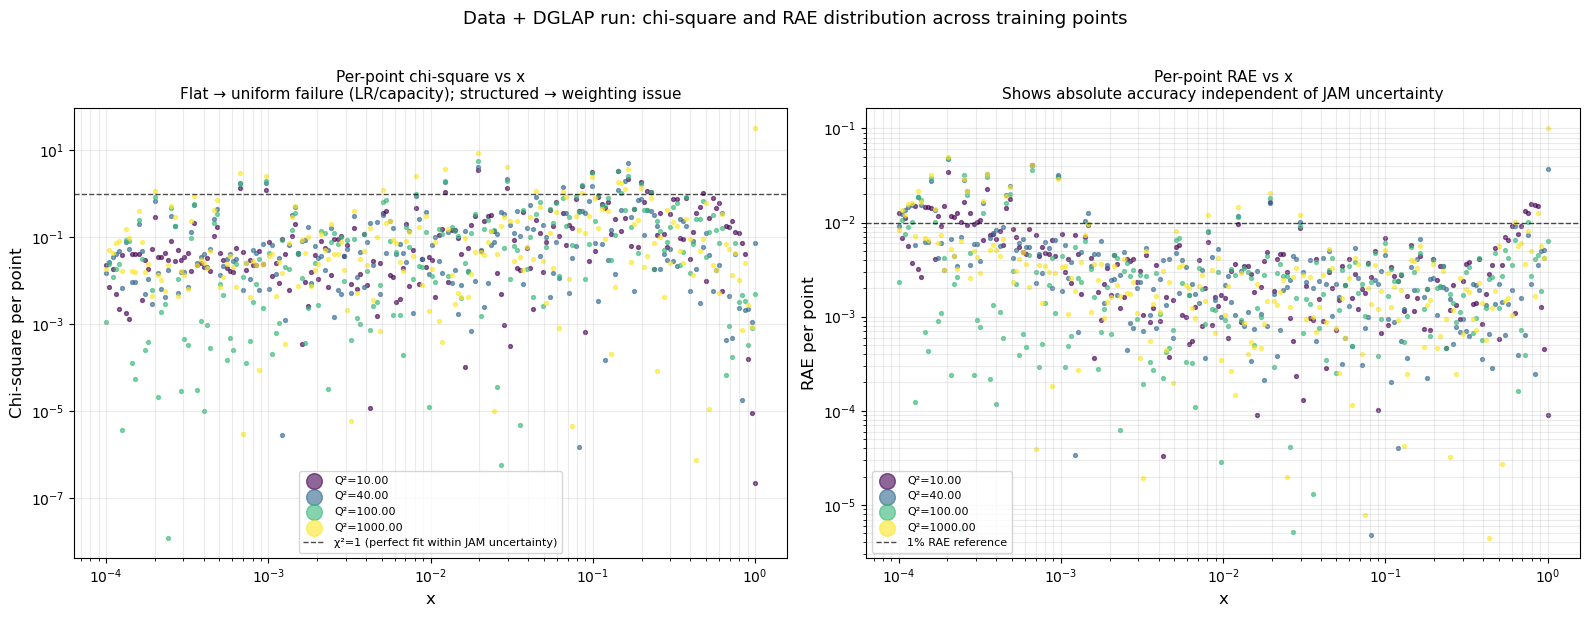

        Q² |    Mean χ² |     Max χ² |  Mean RAE% |   Max RAE%
----------------------------------------------------------
   10.0000 |     0.2422 |     3.6030 |     0.5121 |     4.1189
   40.0000 |     0.2228 |     5.2083 |     0.4954 |     4.6976
  100.0000 |     0.2673 |     5.6956 |     0.3958 |     4.8357
 1000.0000 |     0.4747 |    32.2811 |     0.5158 |    10.0444

Overall mean chi-square : 0.3017  (target ~1.0 for perfect fit)
Overall mean RAE        : 0.4798%
Fraction with chi² > 10 : 0.1%  (points more than ~3σ from JAM median)


In [25]:
# ── Diagnostic: per-point chi-square error ─────────────
model = PINN(N_x).to(device)

CHECKPOINT_PATH = '/work/JAM/rathman/v12_pinn_uv_model_update_resumed.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode for inference
print(f'Model loaded from: {CHECKPOINT_PATH}')

with torch.no_grad():
    pred_train = model(train_X)   # (N_train, N_x)

    # Chi-square per point: ((pred - mu) / sigma)^2
    chi2_per_point = ((pred_train - train_Y) / (train_STD + 1e-12))**2   # (N_train, N_x)
    chi2_np = chi2_per_point.cpu().numpy()

    # RAE per point: |pred - mu| / (|mu| + eps)
    rae_per_point = torch.abs(pred_train - train_Y) / (torch.abs(train_Y) + 1e-6)
    rae_np = rae_per_point.cpu().numpy()

# Extract x and Q² values for colouring
x_vals = x_grid_t.cpu().numpy()                  # shape (N_x,)
q2_vals_train = np.array(train_Q2_vals)          # shape (N_train,)

# ── Plot 1: chi-square per point vs x, coloured by Q² ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
q2_unique = q2_vals_train
colors_diag = plt.cm.viridis(np.linspace(0, 1, len(q2_unique)))

for i, (q2_val, col) in enumerate(zip(q2_unique, colors_diag)):
    ax.scatter(x_vals, chi2_np[i, :],
               s=8, alpha=0.6, color=col, label=f'Q²={q2_val:.2f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Chi-square per point', fontsize=12)
ax.set_title('Per-point chi-square vs x\n'
             'Flat → uniform failure (LR/capacity); '
             'structured → weighting issue', fontsize=11)
ax.axhline(1.0, color='black', lw=1.0, ls='--', alpha=0.7,
           label='χ²=1 (perfect fit within JAM uncertainty)')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

# ── Plot 2: RAE per point vs x, coloured by Q² ───────────────────────────────
ax = axes[1]
for i, (q2_val, col) in enumerate(zip(q2_unique, colors_diag)):
    ax.scatter(x_vals, rae_np[i, :],
               s=8, alpha=0.6, color=col, label=f'Q²={q2_val:.2f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('RAE per point', fontsize=12)
ax.set_title('Per-point RAE vs x\n'
             'Shows absolute accuracy independent of JAM uncertainty', fontsize=11)
ax.axhline(0.01, color='black', lw=1.0, ls='--', alpha=0.7,
           label='1% RAE reference')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

plt.suptitle('Data + DGLAP run: chi-square and RAE distribution across training points',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary statistics per Q² slice ──────────────────────────────────────────
print(f'{"Q²":>10} | {"Mean χ²":>10} | {"Max χ²":>10} | {"Mean RAE%":>10} | {"Max RAE%":>10}')
print('-' * 58)
for i, q2_val in enumerate(q2_unique):
    print(f'{q2_val:>10.4f} | '
          f'{chi2_np[i].mean():>10.4f} | '
          f'{chi2_np[i].max():>10.4f} | '
          f'{rae_np[i].mean()*100:>10.4f} | '
          f'{rae_np[i].max()*100:>10.4f}')

print()
print(f'Overall mean chi-square : {chi2_np.mean():.4f}  (target ~1.0 for perfect fit)')
print(f'Overall mean RAE        : {rae_np.mean()*100:.4f}%')
print(f'Fraction with chi² > 10 : {(chi2_np > 10).mean()*100:.1f}%  '
      f'(points more than ~3σ from JAM median)')

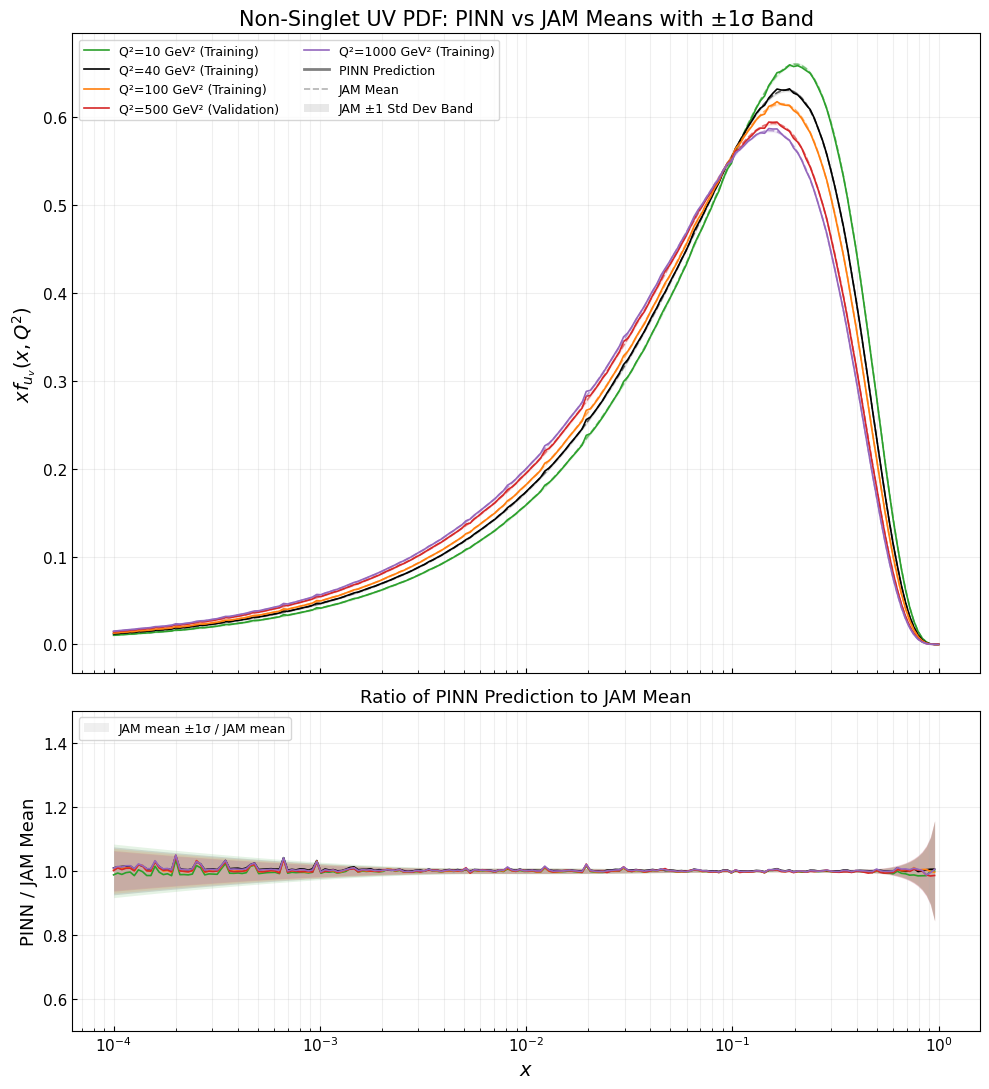

In [28]:
model.eval()

# x-grid (already used in training)
x_vals = x_grid_t.cpu().numpy()          # shape (N_x,)
log_x_vals = np.log(x_vals)

# Colors for Q²
colors = {
    1.6129: '#1f77b4',
    10:     '#2ca02c',
    100:    '#ff7f0e',
    500:    '#d62728',
    1000:   '#9467bd',
}

# Two-panel figure
fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 11),
    gridspec_kw={'height_ratios': [3, 1.5]},
    sharex=True
)

preds_by_q2 = {}
means_by_q2 = {}
los_by_q2   = {}
his_by_q2   = {}

init_pdf_t = torch.tensor(init_pdf, device=device).float()

INPUT_SCALE_Q2 = 1.6129  # skip plotting the model's prediction at its own input scale

for q2 in Q2_vals:
    if q2 == INPUT_SCALE_Q2:
        continue  # not a meaningful prediction — this is the input scale itself

    color = colors.get(q2, 'black')
    label_suffix = ' (Validation)' if q2 == VAL_Q2 else ' (Training)'

    # JAM bands
    uv_reps   = treypdf[q2]['uv']
    mean      = np.mean(uv_reps, axis=0)
    uv_std    = np.std(uv_reps, axis=0)
    lo        = mean - uv_std
    hi        = mean + uv_std

    ax.fill_between(x_vals, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(x_vals, mean, color=color, lw=1.2, ls='--', alpha=0.6)

    # --- PINN input ---
    ln_q2 = np.log(q2)
    ln_q2_t = torch.tensor([ln_q2], device=device).float()
    inp = torch.cat([init_pdf_t, ln_q2_t], dim=0).unsqueeze(0)  # shape (1, N_x+1)

    # NN prediction
    with torch.no_grad():
        pred = model(inp).cpu().numpy().flatten()   # shape (N_x,)

    ax.plot(x_vals, pred, color=color, lw=1.2,
            label=f'Q²={q2} GeV²{label_suffix}')

    preds_by_q2[q2] = pred
    means_by_q2[q2] = mean
    los_by_q2[q2]   = lo
    his_by_q2[q2]   = hi

# --- Top panel formatting ---
line_nn   = plt.Line2D([0], [0], color='grey', lw=2, label='PINN Prediction')
line_med  = plt.Line2D([0], [0], color='grey', lw=1.2, ls='--', alpha=0.6, label='JAM Mean')
line_band = plt.matplotlib.patches.Patch(facecolor='grey', alpha=0.18,
                                         label='JAM ±1 Std Dev Band')

handles_existing, labels_existing = ax.get_legend_handles_labels()
extra_handles = [line_nn, line_med, line_band]
extra_labels  = [h.get_label() for h in extra_handles]

ax.legend(
    handles_existing + extra_handles,
    labels_existing + extra_labels,
    fontsize=9,
    loc='upper left',
    ncol=2
)

ax.set_ylabel(r'$x f_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Means with ±1σ Band', size=15)
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

# --- Ratio panel ---
for q2 in Q2_vals:
    if q2 == INPUT_SCALE_Q2:
        continue  # no prediction to compare — skip in ratio panel too

    color = colors.get(q2, 'black')
    mean  = means_by_q2[q2]
    pred  = preds_by_q2[q2]
    lo    = los_by_q2[q2]
    hi    = his_by_q2[q2]

    safe  = np.abs(mean) > 1e-6
    ratio = np.where(safe, pred / mean, np.nan)
    upper = np.where(safe, hi / mean, np.nan)
    lower = np.where(safe, lo / mean, np.nan)

    ax_ratio.plot(x_vals, ratio, color=color, lw=1.2)
    ax_ratio.fill_between(x_vals, lower, upper, color=color, alpha=0.12, linewidth=0)

ax_ratio.set_xscale('log')
ax_ratio.set_xlabel(r'$x$', size=14)
ax_ratio.set_ylabel(r'PINN / JAM Mean', size=13)
ax_ratio.set_title('Ratio of PINN Prediction to JAM Mean', size=13)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.grid(True, which='both', ls='-', alpha=0.2)
ax_ratio.tick_params(direction='in', which='both', labelsize=11)

band_patch = plt.matplotlib.patches.Patch(
    facecolor='grey', alpha=0.12,
    label='JAM mean ±1σ / JAM mean'
)
ax_ratio.legend(handles=[band_patch], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# Predict PDFs at Extended $Q^2$



In [13]:
# ── Load model ───────────────────────────────────────────────────────────────
#Need to run earlier 'Load Data' cell prior to this cell
model = PINN(N_x).to(device)

CHECKPOINT_PATH = '/work/JAM/rathman/v13_pinn_uv_model.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Model loaded from: {CHECKPOINT_PATH}')

# ── Extended Q² values for prediction ─────────────────────────────────────────
Q2_EXTENDED_VALS = [
    1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000,
    2000, 3000, 4000
]

init_pdf_t = torch.tensor(init_pdf, device=device).float()

predictions_extended_q2 = {}
print('\nGenerating predictions for extended Q² values:')
for q2 in Q2_EXTENDED_VALS:

    ln_q2 = np.log(q2)

    # ln(Q²) as float32
    ln_q2_t = torch.tensor([ln_q2], device=device).float()

    # PINN input = [init_pdf(x-grid), ln(Q²)] 
    inp = torch.cat([init_pdf_t, ln_q2_t], dim=0).unsqueeze(0)

    with torch.no_grad():
        pred = model(inp).cpu().numpy().flatten()

    predictions_extended_q2[q2] = pred
    print(f'  Generated prediction for Q² = {q2} GeV²')

Model loaded from: /work/JAM/rathman/v13_pinn_uv_model.pt

Generating predictions for extended Q² values:
  Generated prediction for Q² = 1.6129 GeV²
  Generated prediction for Q² = 10 GeV²
  Generated prediction for Q² = 15 GeV²
  Generated prediction for Q² = 20 GeV²
  Generated prediction for Q² = 30 GeV²
  Generated prediction for Q² = 40 GeV²
  Generated prediction for Q² = 50 GeV²
  Generated prediction for Q² = 60 GeV²
  Generated prediction for Q² = 70 GeV²
  Generated prediction for Q² = 80 GeV²
  Generated prediction for Q² = 90 GeV²
  Generated prediction for Q² = 100 GeV²
  Generated prediction for Q² = 200 GeV²
  Generated prediction for Q² = 300 GeV²
  Generated prediction for Q² = 400 GeV²
  Generated prediction for Q² = 500 GeV²
  Generated prediction for Q² = 600 GeV²
  Generated prediction for Q² = 700 GeV²
  Generated prediction for Q² = 800 GeV²
  Generated prediction for Q² = 900 GeV²
  Generated prediction for Q² = 1000 GeV²
  Generated prediction for Q² = 2000 Ge

Now plot predictions at a given X as a function of Q^2.

Selected x for Q² evolution (subplot 1): 0.0010 (closest to 0.001)
Selected x for Q² evolution (subplot 2): 0.0196 (closest to 0.02)
Selected x for Q² evolution (subplot 3): 0.0988 (closest to 0.1)
Selected x for Q² evolution (subplot 4): 0.6906 (closest to 0.7)


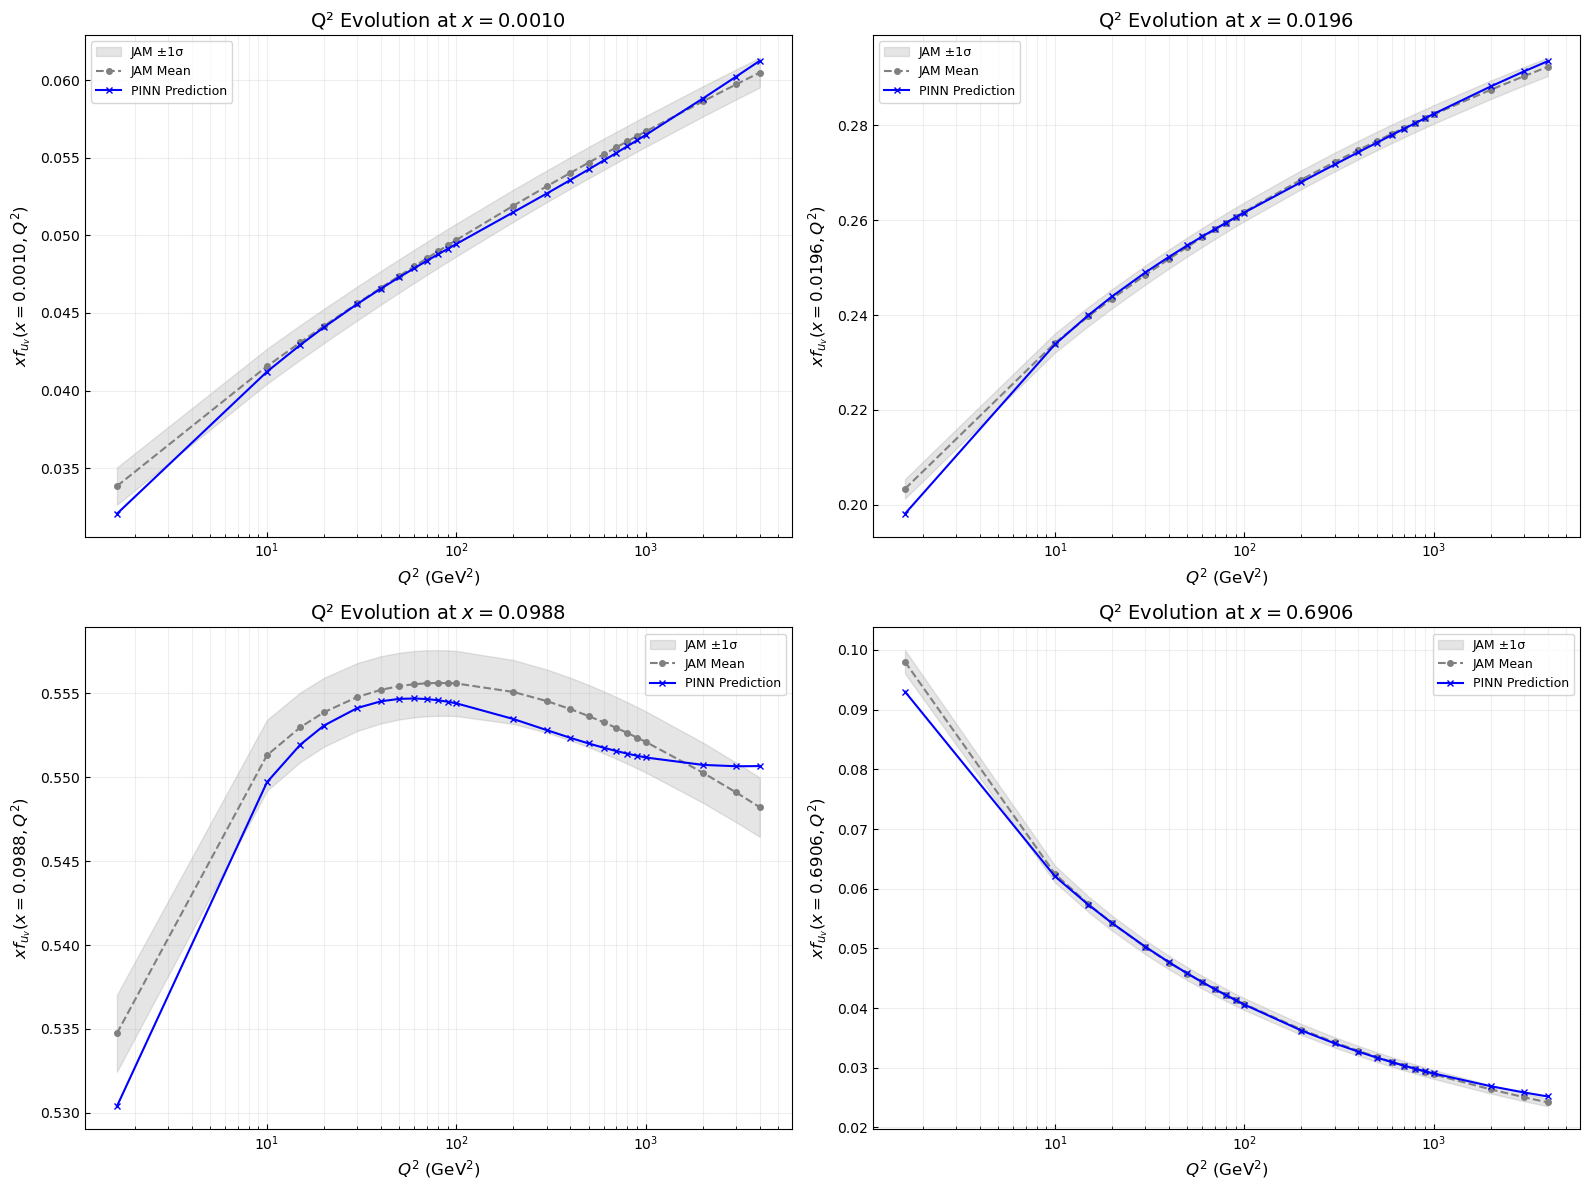

In [14]:
# Fixed x-values to examine Q² evolution
FIXED_X_VALS = [1e-3, 0.02, 0.1, 0.7]

# Use your extended x-grid (same grid used for predictions)
X_ext = x_grid_t.cpu().numpy()
N_x_ext = len(X_ext)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, fixed_x in enumerate(FIXED_X_VALS):
    ax = axes[i]

    # Find nearest x-grid index
    x_idx = (np.abs(X_ext - fixed_x)).argmin()
    actual_x_val = X_ext[x_idx]
    print(f"Selected x for Q² evolution (subplot {i+1}): {actual_x_val:.4f} (closest to {fixed_x})")

    # Storage for DataFrame
    q2_values_plot = []
    model_predictions_at_x = []
    jam_mean_at_x = []
    jam_lo_at_x = []
    jam_hi_at_x = []

    for q2 in sorted(Q2_EXTENDED_VALS):
        q2_values_plot.append(q2)

        # PINN prediction at this x
        model_predictions_at_x.append(predictions_extended_q2[q2][x_idx])

        # JAM data (if available)
        if q2 in treypdf:
            uv_reps = treypdf[q2]['uv']
            uv_mean = np.mean(uv_reps, axis=0)
            uv_std  = np.std(uv_reps, axis=0)
            uv_lo   = uv_mean - uv_std
            uv_hi   = uv_mean + uv_std

            jam_mean_at_x.append(uv_mean[x_idx])
            jam_lo_at_x.append(uv_lo[x_idx])
            jam_hi_at_x.append(uv_hi[x_idx])
        else:
            jam_mean_at_x.append(np.nan)
            jam_lo_at_x.append(np.nan)
            jam_hi_at_x.append(np.nan)

    # Build DataFrame for this x
    df_q2_evolution_current_x = pd.DataFrame({
        'Q2': q2_values_plot,
        'Model_Prediction': model_predictions_at_x,
        'JAM_Mean': jam_mean_at_x,
        'JAM_Lo': jam_lo_at_x,
        'JAM_Hi': jam_hi_at_x
    })

    # JAM band + mean (only where JAM exists)
    ajam = df_q2_evolution_current_x.dropna(subset=['JAM_Mean'])

    ax.fill_between(
        ajam['Q2'], ajam['JAM_Lo'], ajam['JAM_Hi'],
        color='grey', alpha=0.2, label='JAM ±1σ'
    )
    ax.plot(
        ajam['Q2'], ajam['JAM_Mean'],
        color='grey', linestyle='--', marker='o', markersize=4,
        label='JAM Mean'
    )

    # PINN predictions
    ax.plot(
        df_q2_evolution_current_x['Q2'],
        df_q2_evolution_current_x['Model_Prediction'],
        color='blue', linestyle='-', marker='x', markersize=4,
        label='PINN Prediction'
    )

    ax.set_xscale('log')
    ax.set_xlabel(r'$Q^2$ (GeV$^2$)', size=12)
    ax.set_ylabel(r'$xf_{{u_v}}(x={:.4f}, Q^2)$'.format(actual_x_val), size=12)
    ax.set_title(f'Q² Evolution at $x={actual_x_val:.4f}$', size=14)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.tick_params(direction='in', which='both', labelsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()